In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Preprocessing & Scaling
from sklearn.preprocessing import RobustScaler, PowerTransformer

# Models
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

# Feature Selection
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance

# Stats
from scipy.stats import shapiro, chi2_contingency

# Fairness
from fairlearn.reductions import ExponentiatedGradient, DemographicParity, EqualizedOdds

# Oversampling
from imblearn.over_sampling import SMOTE

In [2]:
#Loading the DataSet
df = pd.read_csv('heart999.csv')

# Initial Data Exploration
print(df.shape)
print(df.info())
print(df.describe())

#Checking initial Data
df.head()

(918, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None
              Age   RestingBP  Cholesterol   FastingBS       MaxHR  \
count  918.000000  918.000000   918.000000  918.000000  918.000000   
mean    53.510893  132.396514   198.799564    0

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
#replace 0 with NaN
df['RestingBP'] = df['RestingBP'].replace(0, np.nan)
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)

In [4]:
df.info()

# Statistical summary of numerical features
print("\nNumerical Summary:")
df.describe()

# Missing value percentages
print("\nMissing Value Percentages:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       917 non-null    float64
 4   Cholesterol     746 non-null    float64
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 86.2+ KB

Numerical Summary:

Missing Value Percentages:
             Missing Count  Missing %
RestingBP                1       0.11
Cholesterol            172      18.74


In [5]:
#Filling NaN values with median based on gender of the patient
df['RestingBP'] = df.groupby('Sex')['RestingBP'].transform(lambda x: x.fillna(x.median()))
df['Cholesterol'] = df.groupby('Sex')['Cholesterol'].transform(lambda x: x.fillna(x.median()))

In [6]:
#Checking if NaN is pending
print(df[['RestingBP', 'Cholesterol']].isnull().sum())

RestingBP      0
Cholesterol    0
dtype: int64


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    float64
 4   Cholesterol     918 non-null    float64
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 86.2+ KB


In [8]:
#Defining Numeraical columns
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

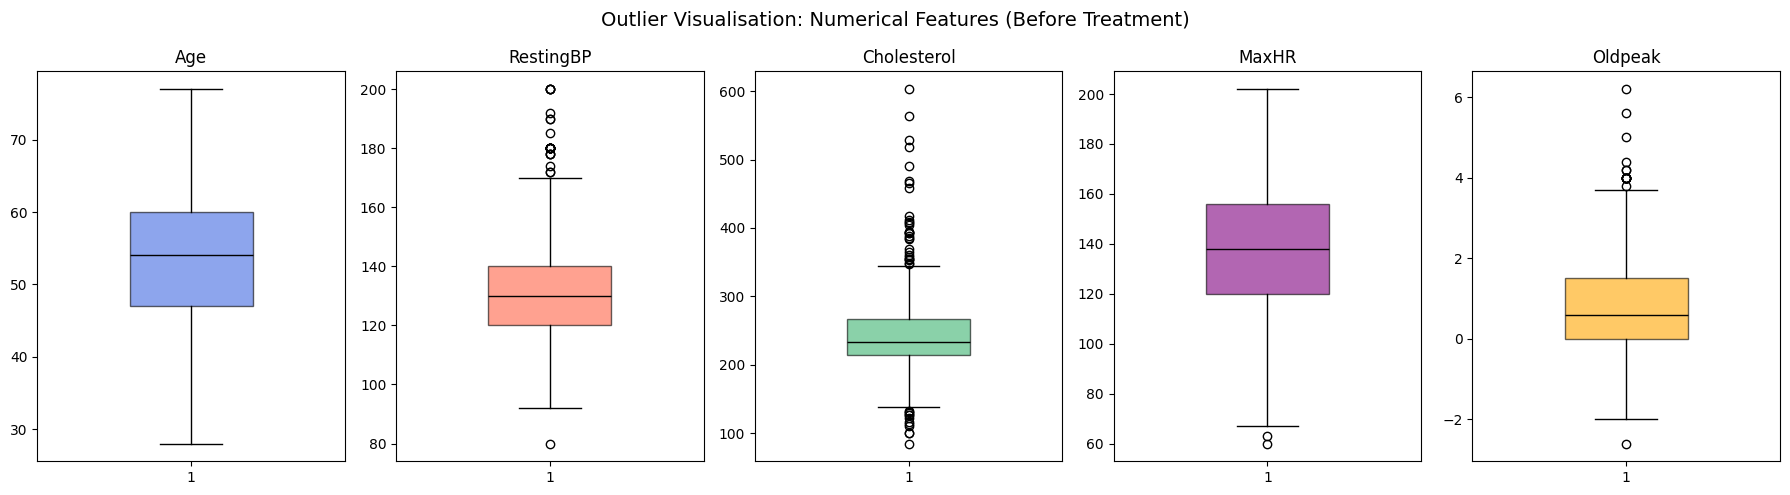

In [9]:
# Plotting Boxplots to identify which features have the most extreme values

colors = ['royalblue', 'tomato', 'mediumseagreen', 'purple', 'orange']
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(18, 5))

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(
        df[col],
        patch_artist=True,
        widths=0.4,
        boxprops=dict(facecolor=colors[i], alpha=0.6),
        medianprops=dict(color='black')
    )
    axes[i].set_title(col)

plt.suptitle("Outlier Visualisation: Numerical Features (Before Treatment)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# IQR (Interquartile Range) method for univariate outlier detection

Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

iqr_flags = (
    (df[numerical_cols] < (Q1 - 1.5 * IQR)) |
    (df[numerical_cols] > (Q3 + 1.5 * IQR))
)

print("IQR Outlier Count per Feature:")
print(iqr_flags.sum().sort_values(ascending=False))

IQR Outlier Count per Feature:
Cholesterol    41
RestingBP      27
Oldpeak        16
MaxHR           2
Age             0
dtype: int64


In [ ]:
# contamination is 0.05 means as we expect ~5% anomalies which is conservative for medical data

from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    random_state=42
)

iso_preds = iso_model.fit_predict(df[numerical_cols])
iso_outlier_count = (iso_preds == -1).sum()

df['IsolationForest_Outlier'] = (iso_preds == -1).astype(int)

print(f"Isolation Forest flagged: {iso_outlier_count} anomalous patients")
print(f"That is {iso_outlier_count/len(df)*100:.1f}% of the dataset")

Isolation Forest flagged: 46 anomalous patients
That is 5.0% of the dataset


In [12]:
#Checking outlier distribution across gender
outlier_cols = numerical_cols
Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

iqr_any_outlier = (
    (df[numerical_cols] < (Q1 - 1.5 * IQR)) |
    (df[numerical_cols] > (Q3 + 1.5 * IQR))
).any(axis=1)

print("Outlier distribution by gender:")
print(df.groupby('Sex').apply(lambda x: iqr_any_outlier[x.index].sum()))
print("\nAs percentage of each gender group:")
print(df.groupby('Sex').apply(lambda x: iqr_any_outlier[x.index].mean() * 100).round(1))

Outlier distribution by gender:
Sex
F    20
M    61
dtype: int64

As percentage of each gender group:
Sex
F    10.4
M     8.4
dtype: float64


/var/folders/vk/rlj4x5g95nq_dq2fhn9j1y4w0000gn/T/ipykernel_34757/3885064855.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(df.groupby('Sex').apply(lambda x: iqr_any_outlier[x.index].sum()))
/var/folders/vk/rlj4x5g95nq_dq2fhn9j1y4w0000gn/T/ipykernel_34757/3885064855.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(df.groupby('Sex').apply(lambda x: iqr_any_outlier[x.index].mean() * 100).

In [ ]:
# Winsorization caps extremes at 1st/99th percentile without removal of rows
df_clean = df.copy()

for col in numerical_cols:
    lower = df_clean[col].quantile(0.01)
    upper = df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

# Verifying the effect
Q1 = df_clean[numerical_cols].quantile(0.25)
Q3 = df_clean[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

iqr_after = (
    (df_clean[numerical_cols] < (Q1 - 1.5 * IQR)) |
    (df_clean[numerical_cols] > (Q3 + 1.5 * IQR))
).any(axis=1)

print("Outlier distribution AFTER Winsorization:")
print(df_clean.groupby('Sex').apply(
    lambda x: iqr_after[x.index].sum(), include_groups=False
))
print("\nAs percentage of each gender group:")
print(df_clean.groupby('Sex').apply(
    lambda x: iqr_after[x.index].mean() * 100, include_groups=False
).round(1))

print("\nRows before:", len(df))
print("Rows after :", len(df_clean))
print("No rows were deleted — only extreme values were capped")

df = df_clean.copy()

Outlier distribution AFTER Winsorization:
Sex
F    20
M    57
dtype: int64

As percentage of each gender group:
Sex
F    10.4
M     7.9
dtype: float64

Rows before: 918
Rows after : 918
No rows were deleted — only extreme values were capped


In [ ]:
# Gender-Stratified Winsorization

df_clean = df.copy()

for gender in ['M', 'F']:
    mask = df_clean['Sex'] == gender
    for col in numerical_cols:
        lower = df_clean.loc[mask, col].quantile(0.01)
        upper = df_clean.loc[mask, col].quantile(0.99)
        df_clean.loc[mask, col] = df_clean.loc[mask, col].clip(lower=lower, upper=upper)

# Verify per gender
Q1 = df_clean[numerical_cols].quantile(0.25)
Q3 = df_clean[numerical_cols].quantile(0.75)
IQR = Q3 - Q1

iqr_after = (
    (df_clean[numerical_cols] < (Q1 - 1.5 * IQR)) |
    (df_clean[numerical_cols] > (Q3 + 1.5 * IQR))
).any(axis=1)

print("Outlier distribution AFTER Gender-Stratified Winsorization:")
print(df_clean.groupby('Sex').apply(
    lambda x: iqr_after[x.index].sum(), include_groups=False
))
print("\nAs percentage of each gender group:")
print(df_clean.groupby('Sex').apply(
    lambda x: iqr_after[x.index].mean() * 100, include_groups=False
).round(1))

print("\nRows before:", len(df))
print("Rows after :", len(df_clean))

df = df_clean.copy()

Outlier distribution AFTER Gender-Stratified Winsorization:
Sex
F    20
M    57
dtype: int64

As percentage of each gender group:
Sex
F    10.4
M     7.9
dtype: float64

Rows before: 918
Rows after : 918


/var/folders/vk/rlj4x5g95nq_dq2fhn9j1y4w0000gn/T/ipykernel_34757/1172422289.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[49.   48.   45.   48.   37.   42.   54.   43.   43.   49.   53.   43.
 41.   48.   48.   54.   54.   47.   41.   52.   51.   43.   50.   37.
 45.   44.   35.   53.   49.   52.   39.   40.   48.   59.   49.   33.
 59.   35.   47.   52.   58.   34.   48.   54.   61.   43.   56.   43.
 52.   46.   54.   50.   41.   62.   57.   32.   50.   56.   32.   51.
 48.   37.   38.   54.   43.   53.   55.   51.   55.   54.   47.   32.
 45.   57.   54.   51.   55.   51.   48.   47.   62.   51.   38.   64.
 64.   73.   38.   62.   50.   66.   63.   64.   54.   61.   51.   54.
 67.   73.08 63.   57.   71.   54.   48.   46.   51.   71.   37.   62.
 65.   65.   63.   45.   41.   60.   59.   51.   60.   58.   44.   57.
 73.08 67.   39.   42.   41.   61.   64.   50.   44.   49.   60.   45.
 55.   

### Winsorization Result

Winsorization at the 1st/99th percentile did not reduce the female outlier 
rate (remained at 10.4%). Further investigation with gender-stratified caps 
produced the same result.

This is consistent with the dataset being 79% male (725M vs 193F) — the IQR 
bounds are dominated by male physiology, meaning female Cholesterol and 
RestingBP values that fall outside these bounds likely reflect genuine 
physiological differences rather than data errors.

Winsorization is retained in the pipeline for completeness and to cap the 
most extreme male outliers (male count reduced from 61 to 57), but its 
limited effect on the female subset is acknowledged as a limitation.

In [ ]:
# Shapiro-Wilk Normality Test
# Tests whether each numerical feature follows a normal distribution

from scipy.stats import shapiro

print(f"{'Feature':<15} | {'P-Value':<30} | {'Result'}")
print("-" * 60)

non_normal = []

for col in numerical_cols:
    stat, p_value = shapiro(df[col])
    result = "NOT Normal" if p_value < 0.05 else "Normal"
    print(f"{col:<15} | {p_value:<30} | {result}")
    if p_value < 0.05:
        non_normal.append(col)

print(f"\n{len(non_normal)} out of {len(numerical_cols)} features are non-normal")
print(f"Non-normal features: {non_normal}")
print("\nYeo-Johnson Power Transformation will be applied in the next step")

Feature         | P-Value                        | Result
------------------------------------------------------------
Age             | 4.453764761569523e-07          | NOT Normal ✗
RestingBP       | 4.414656509855853e-12          | NOT Normal ✗
Cholesterol     | 4.0137615451833073e-16         | NOT Normal ✗
MaxHR           | 3.5623434623348256e-07         | NOT Normal ✗
Oldpeak         | 9.488633490006165e-29          | NOT Normal ✗

5 out of 5 features are non-normal
Non-normal features: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

Yeo-Johnson Power Transformation will be applied in the next step


In [ ]:
# Yeo-Johnson Power Transformation for transformation toward normal distribution

from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')
df[numerical_cols] = pt.fit_transform(df[numerical_cols])

print("Yeo-Johnson Transformation applied to:")
print(numerical_cols)
print("\nSample of transformed values:")
print(df[numerical_cols].head())

print("\nPost-transformation statistics:")
print(df[numerical_cols].describe().round(3))

Yeo-Johnson Transformation applied to:
['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

Sample of transformed values:
        Age  RestingBP  Cholesterol     MaxHR   Oldpeak
0 -1.419503   0.506049     0.990179  1.419175 -0.973270
1 -0.512144   1.488910    -1.378561  0.759234  0.464790
2 -1.706461  -0.057132     0.882404 -1.529489 -0.973270
3 -0.616231   0.397704    -0.528248 -1.148098  0.853243
4  0.019829   1.018928    -0.987352 -0.604181 -0.973270

Post-transformation statistics:
           Age  RestingBP  Cholesterol    MaxHR  Oldpeak
count  918.000    918.000      918.000  918.000  918.000
mean     0.000      0.000       -0.000   -0.000    0.000
std      1.001      1.001        1.001    1.001    1.001
min     -2.166     -2.555       -2.955   -2.302   -2.582
25%     -0.720     -0.680       -0.528   -0.683   -0.973
50%      0.020     -0.057       -0.082    0.030    0.042
75%      0.682      0.506        0.585    0.759    0.853
max      2.323      2.323        2.846    2.005  

In [ ]:
# Finding the Categorical columns

categorical_cols = ['RestingECG', 'ChestPainType', 'ExerciseAngina', 
                    'FastingBS', 'ST_Slope', 'Sex']

# Target variable
TARGET = 'HeartDisease'

print("Categorical columns:", categorical_cols)
print("Numerical columns  :", numerical_cols)
print("Target             :", TARGET)

Categorical columns: ['RestingECG', 'ChestPainType', 'ExerciseAngina', 'FastingBS', 'ST_Slope', 'Sex']
Numerical columns  : ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
Target             : HeartDisease


In [ ]:
df = df.drop(columns=['IsolationForest_Outlier'], errors='ignore')
# One-Hot Encoding for categorical features
df_encoded = pd.get_dummies(df, columns=categorical_cols)

# Convert boolean dummy columns to integer type (0/1) for better compatibility with ML models
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print(f"Shape before encoding: {df.shape}")
print(f"Shape after encoding : {df_encoded.shape}")
print(f"\nNew columns created  : {df_encoded.shape[1] - df.shape[1] + len(categorical_cols)}")
print(f"\nAll columns after encoding:")
print(df_encoded.columns.tolist())
print(f"\nFirst 5 rows:")
df_encoded.head()

Shape before encoding: (918, 12)
Shape after encoding : (918, 22)

New columns created  : 16

All columns after encoding:
['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'HeartDisease', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'FastingBS_0', 'FastingBS_1', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up', 'Sex_F', 'Sex_M']

First 5 rows:


,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,HeartDisease,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ChestPainType_ASY,...,ChestPainType_TA,ExerciseAngina_N,ExerciseAngina_Y,FastingBS_0,FastingBS_1,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up,Sex_F,Sex_M
0,-1.419503,0.506049,0.990179,1.419175,-0.973270,0,0,1,0,0,...,0,1,0,1,0,0,0,1,0,1
1,-0.512144,1.488910,-1.378561,0.759234,0.464790,1,0,1,0,0,...,0,1,0,1,0,0,1,0,1,0
2,-1.706461,-0.057132,0.882404,-1.529489,-0.973270,0,0,0,1,0,...,0,1,0,1,0,0,0,1,0,1
3,-0.616231,0.397704,-0.528248,-1.148098,0.853243,1,0,1,0,1,...,0,0,1,1,0,0,1,0,1,0
4,0.019829,1.018928,-0.987352,-0.604181,-0.973270,0,0,1,0,0,...,0,1,0,1,0,0,0,1,0,1


In [ ]:
# Train-Test Split
target = 'HeartDisease'
X = df_encoded.drop(columns=[target])
y = df_encoded[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 734 samples
Testing set size: 184 samples


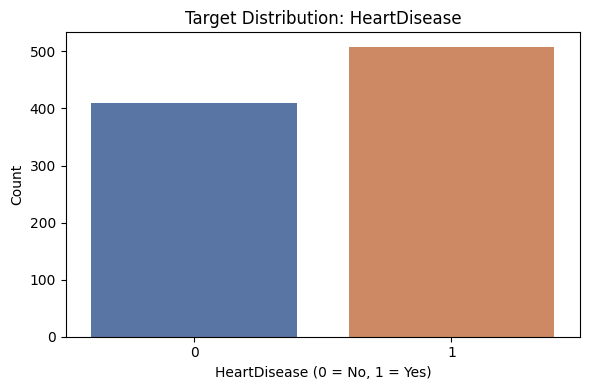

HeartDisease
1    508
0    410
Name: count, dtype: int64

Class balance: {1: 0.553, 0: 0.447}


In [ ]:
# Target distribution

plt.figure(figsize=(6, 4))
sns.countplot(
    data=df,
    x=TARGET,
    hue=TARGET,
    palette={0: '#4C72B0', 1: '#DD8452'},
    legend=False
)
plt.title('Target Distribution: HeartDisease')
plt.xlabel('HeartDisease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(df[TARGET].value_counts())
print(f"\nClass balance: {df[TARGET].value_counts(normalize=True).round(3).to_dict()}")

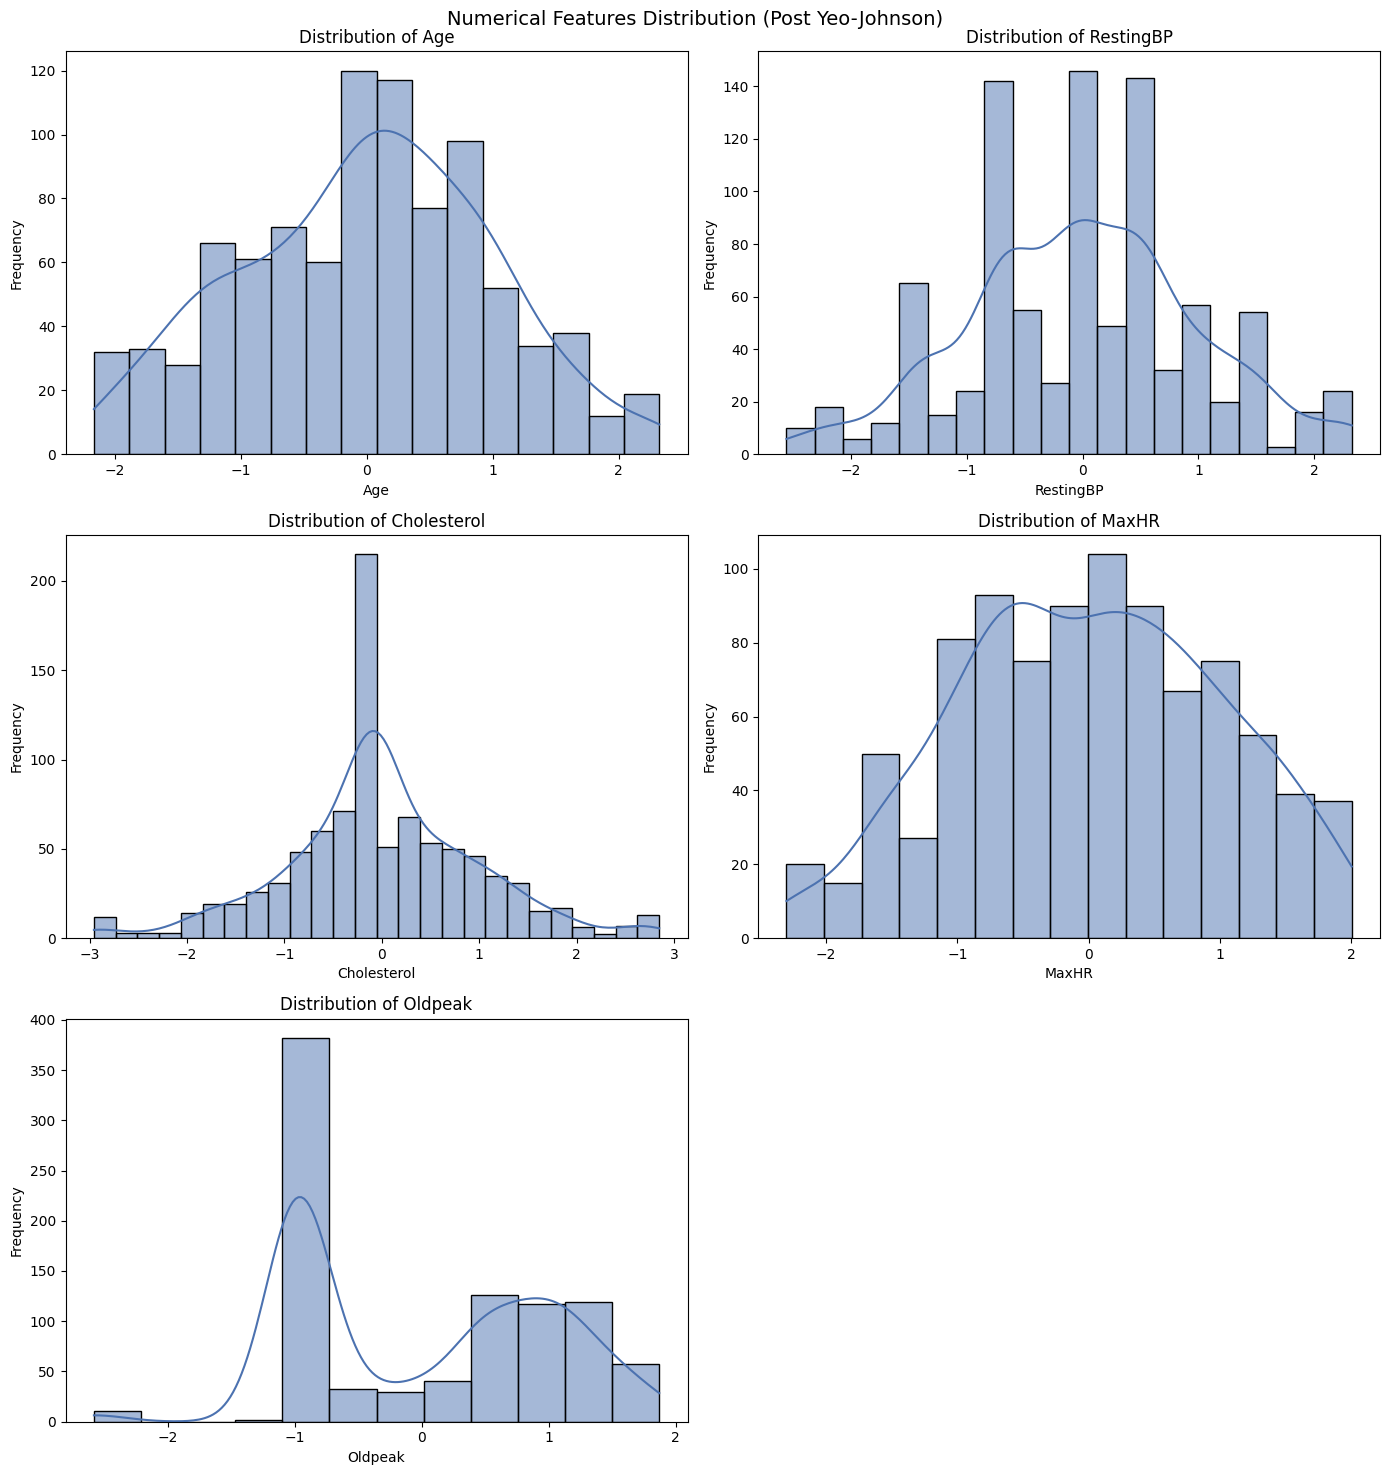

In [ ]:
# Distribution of each numerical feature after Yeo-Johnson transformation

n_cols = 2
n_rows = math.ceil(len(numerical_cols) / n_cols)

plt.figure(figsize=(14, 5 * n_rows))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col], kde=True, color='#4C72B0', edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.suptitle('Numerical Features Distribution (Post Yeo-Johnson)', fontsize=14)
plt.tight_layout()
plt.show()

/var/folders/vk/rlj4x5g95nq_dq2fhn9j1y4w0000gn/T/ipykernel_34757/2002369149.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel', edgecolor='black')
/var/folders/vk/rlj4x5g95nq_dq2fhn9j1y4w0000gn/T/ipykernel_34757/2002369149.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel', edgecolor='black')
/var/folders/vk/rlj4x5g95nq_dq2fhn9j1y4w0000gn/T/ipykernel_34757/2002369149.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='pastel', edgecolor='bla

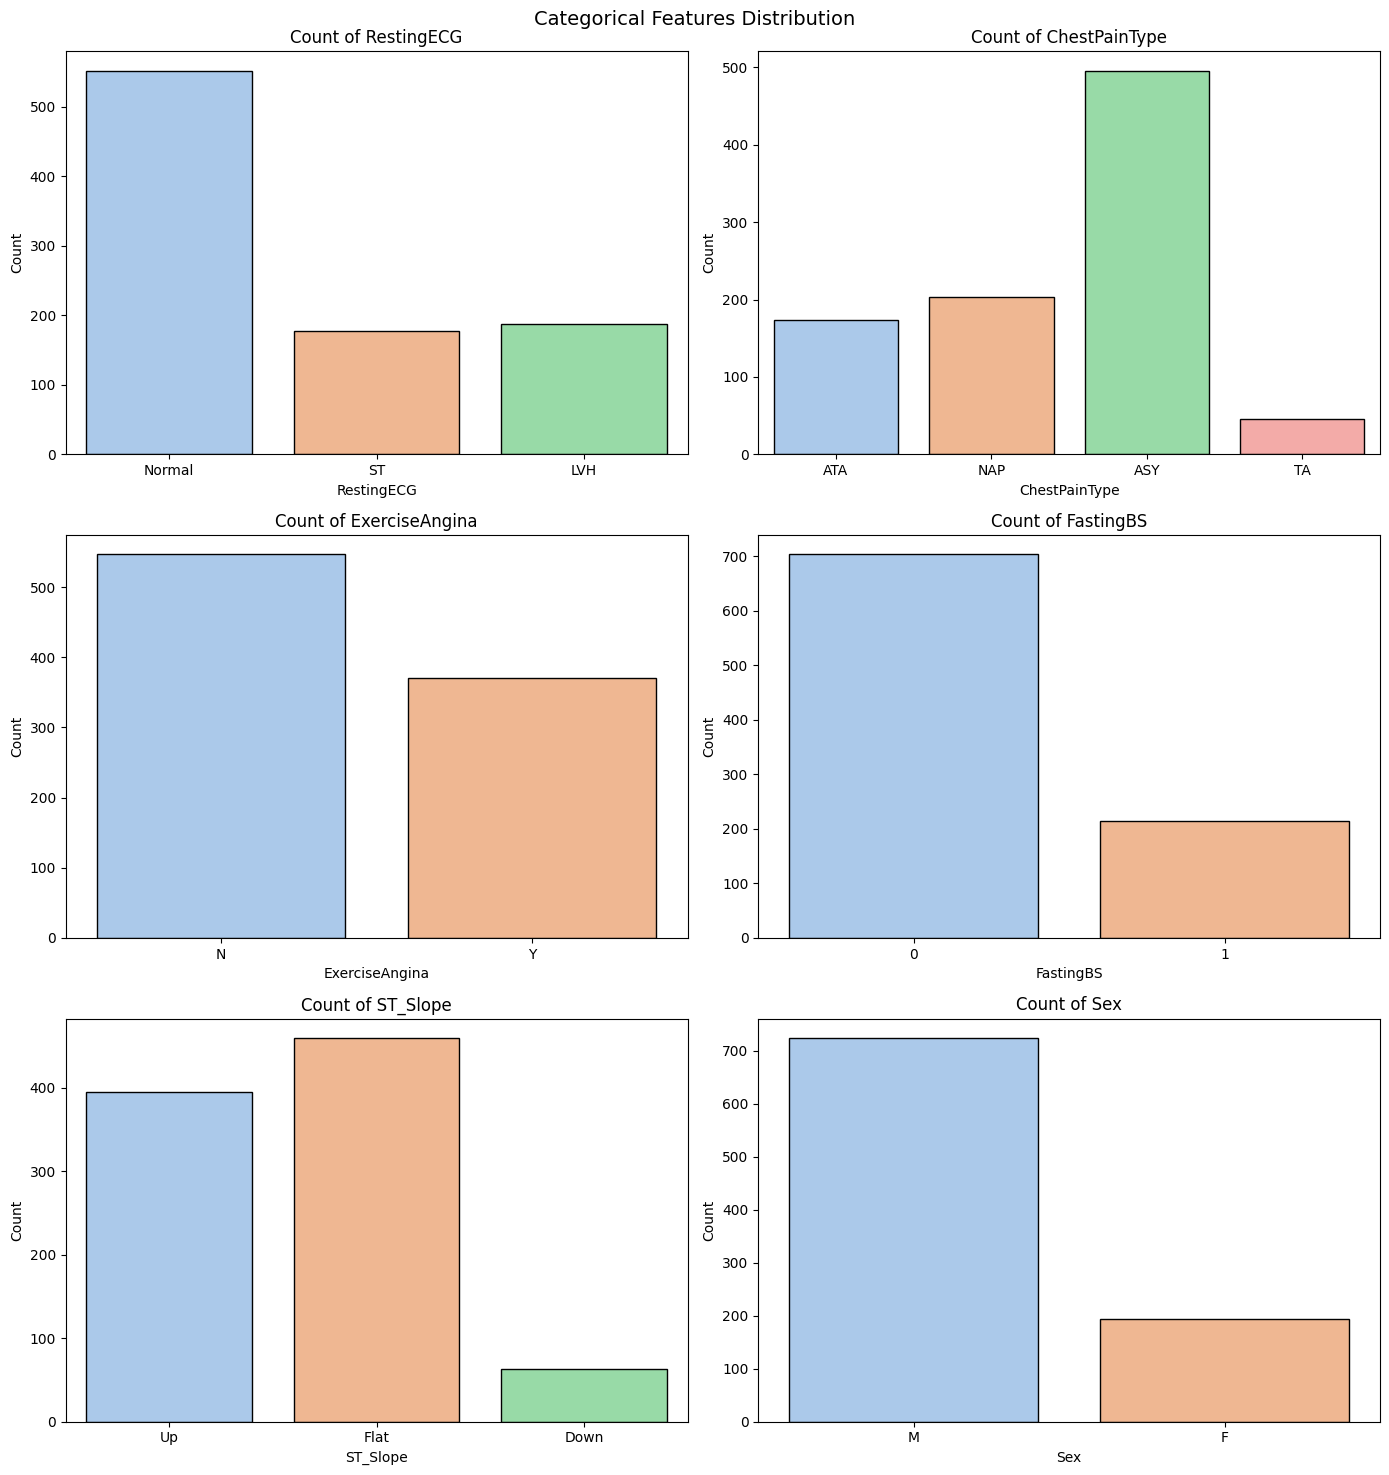

In [ ]:
# Count of categorical features
n_cols = 2
n_rows = math.ceil(len(categorical_cols) / n_cols)

plt.figure(figsize=(14, 5 * n_rows))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.countplot(data=df, x=col, palette='pastel', edgecolor='black')
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.suptitle('Categorical Features Distribution', fontsize=14)
plt.tight_layout()
plt.show()

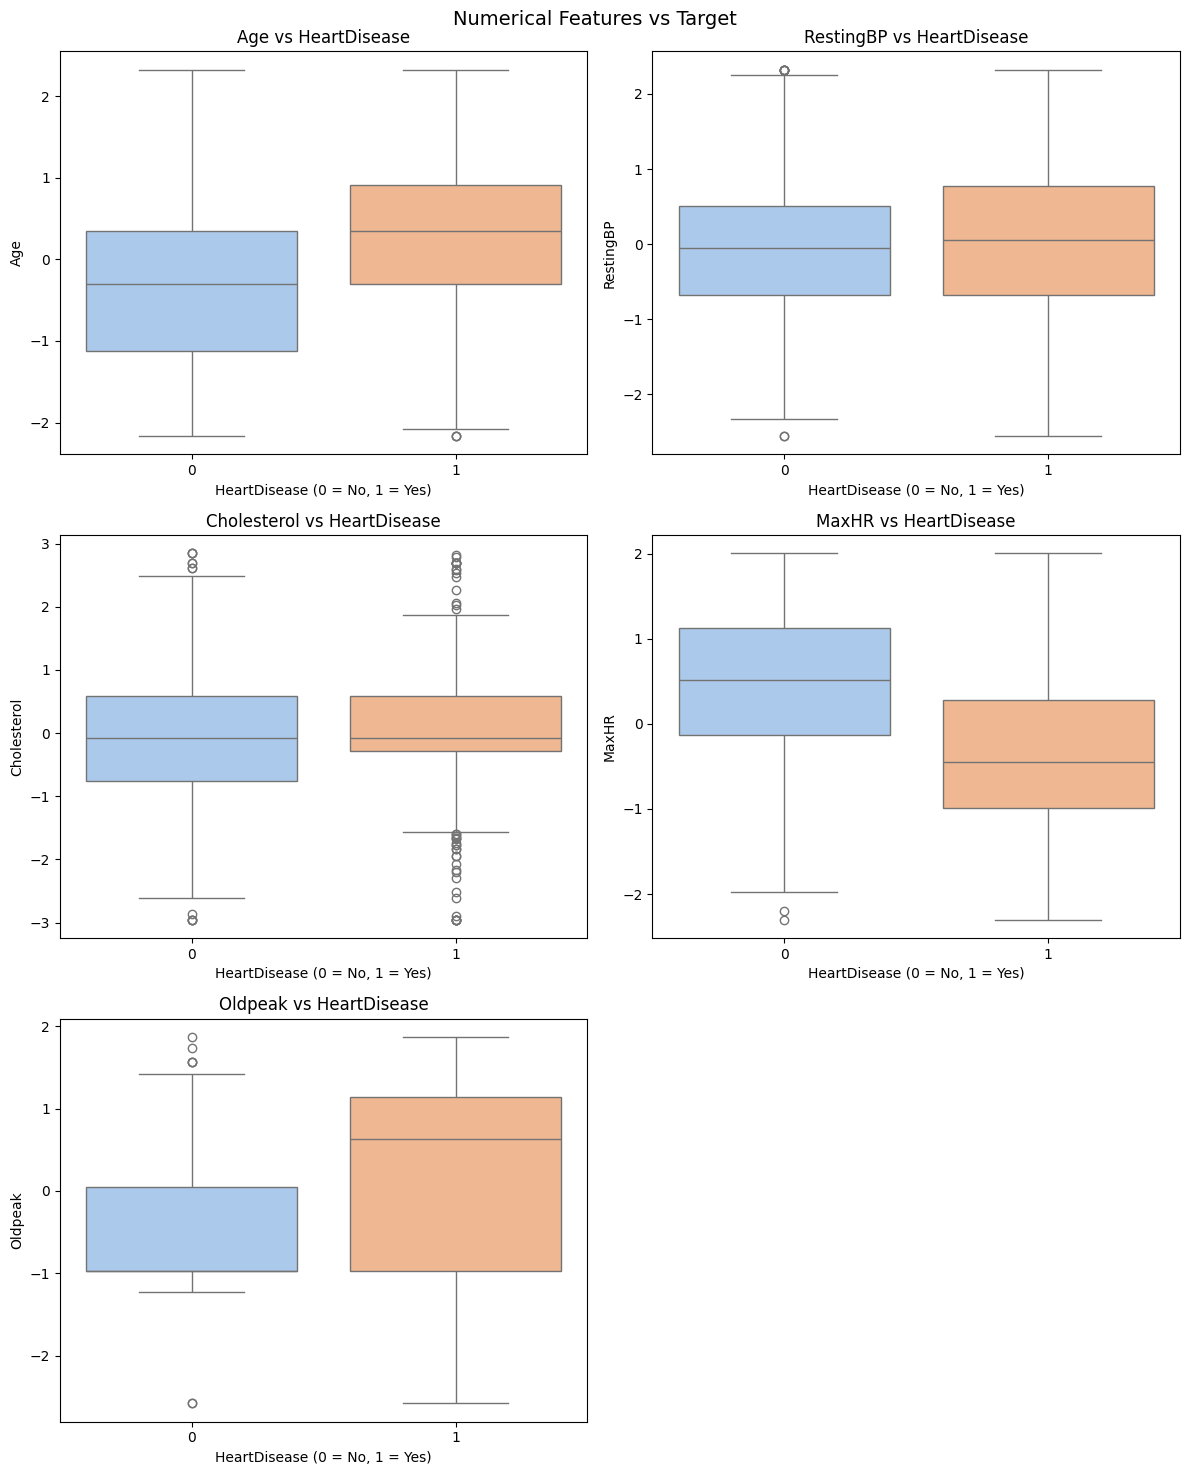

In [ ]:
# boxplots of numerical features split by HeartDisease

n_cols = 2
n_rows = math.ceil(len(numerical_cols) / n_cols)

plt.figure(figsize=(12, 5 * n_rows))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(
        x=df[TARGET],
        y=df[col],
        hue=df[TARGET],
        palette='pastel',
        legend=False
    )
    plt.title(f'{col} vs HeartDisease')
    plt.xlabel('HeartDisease (0 = No, 1 = Yes)')
    plt.ylabel(col)

plt.suptitle('Numerical Features vs Target', fontsize=14)
plt.tight_layout()
plt.show()

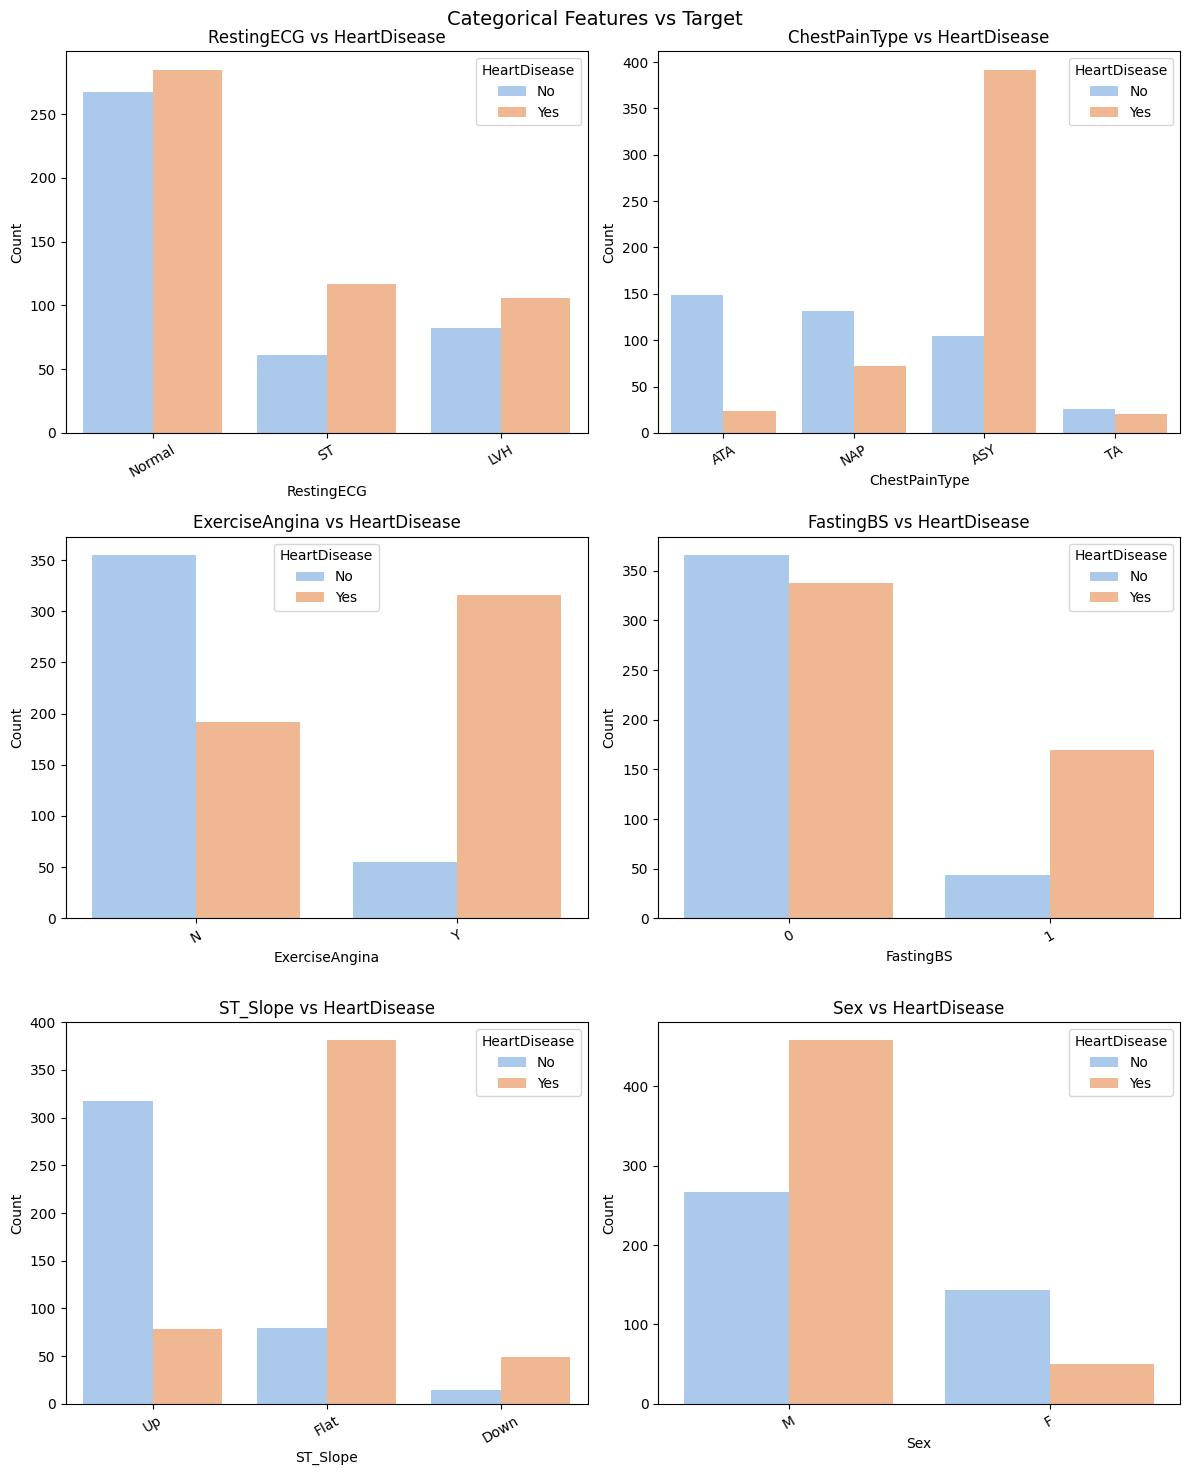

In [ ]:
# Countplots of categorical features to check which values are associated with heart disease most

n_cols = 2
n_rows = math.ceil(len(categorical_cols) / n_cols)

plt.figure(figsize=(12, 5 * n_rows))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.countplot(
        data=df,
        x=col,
        hue=TARGET,
        palette='pastel'
    )
    plt.title(f'{col} vs HeartDisease')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=30)
    plt.legend(title='HeartDisease', labels=['No', 'Yes'])

plt.suptitle('Categorical Features vs Target', fontsize=14)
plt.tight_layout()
plt.show()

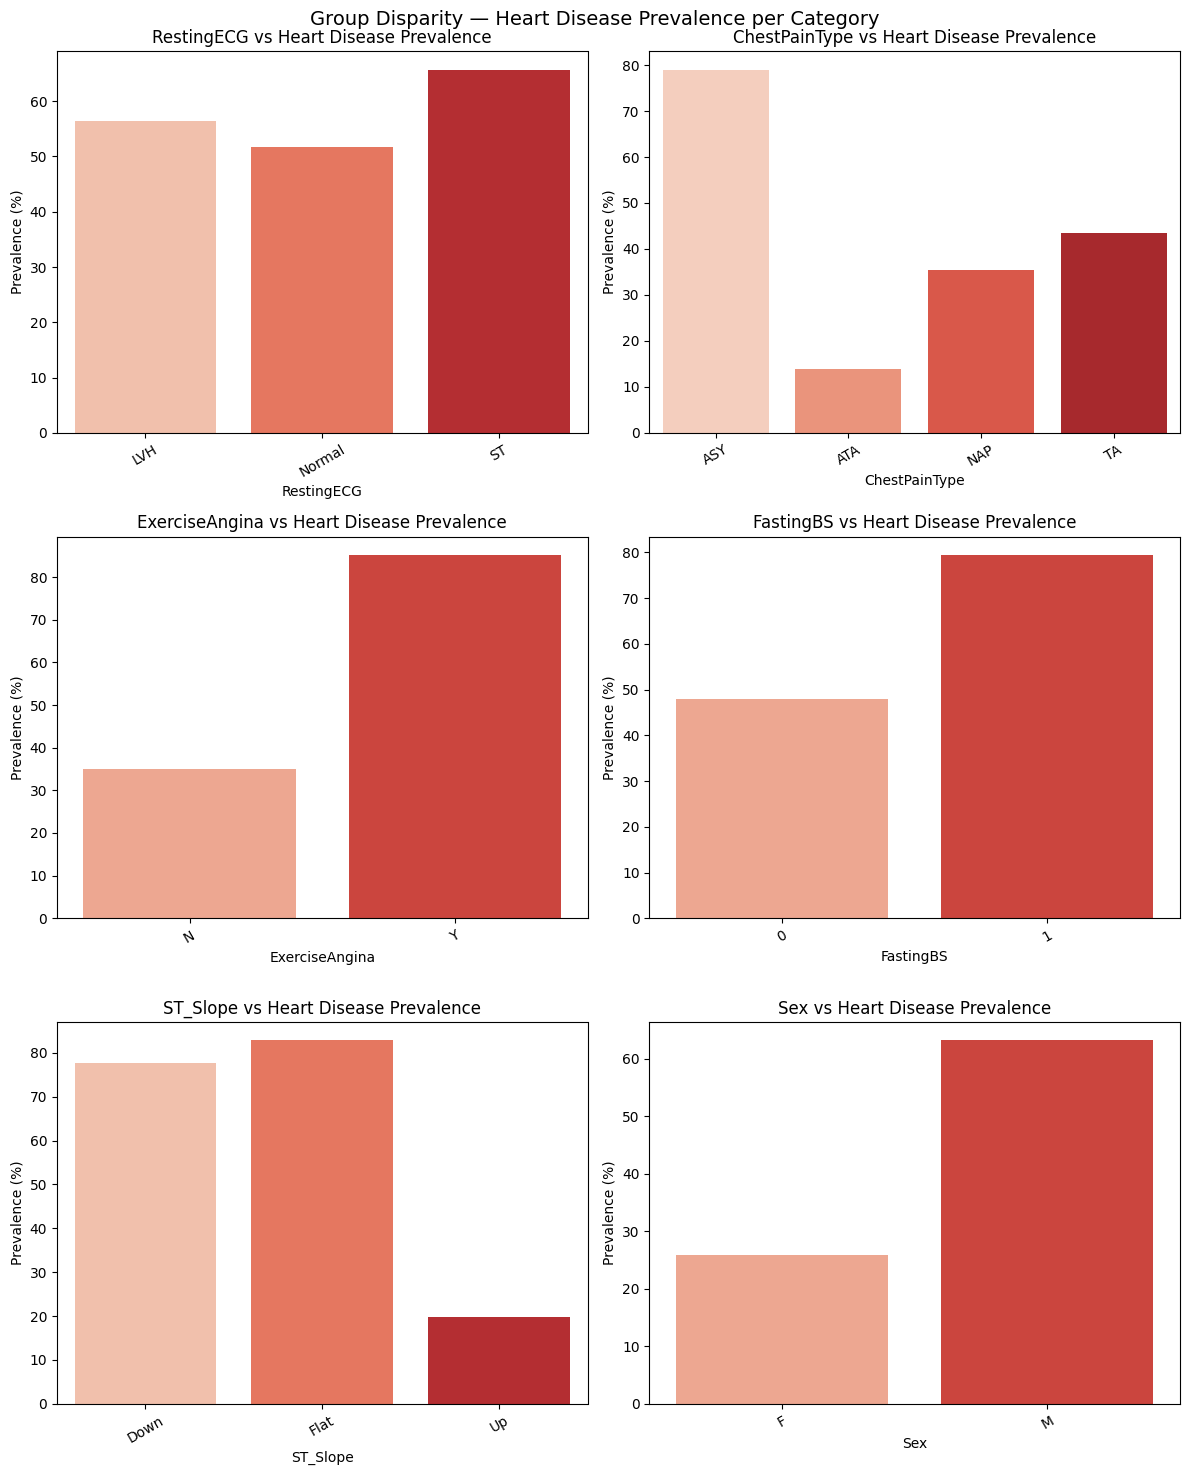

In [ ]:
# Group Disparity Heart Disease Prevalence per Categorical Feature

def plot_all_categorical_disparity(df, categorical_cols, target_col):
    n_cols = 2
    n_rows = math.ceil(len(categorical_cols) / n_cols)
    
    plt.figure(figsize=(12, 5 * n_rows))

    for i, col in enumerate(categorical_cols, 1):
        plt.subplot(n_rows, n_cols, i)

        prevalence = (
            df.groupby(col)[target_col]
            .mean()
            .reset_index()
        )
        prevalence[target_col] = prevalence[target_col] * 100

        sns.barplot(
            data=prevalence,
            x=col,
            y=target_col,
            hue=col,
            palette="Reds",
            legend=False
        )

        plt.title(f"{col} vs Heart Disease Prevalence")
        plt.xlabel(col)
        plt.ylabel("Prevalence (%)")
        plt.xticks(rotation=30)

    plt.suptitle("Group Disparity — Heart Disease Prevalence per Category", fontsize=14)
    plt.tight_layout()
    plt.show()

plot_all_categorical_disparity(df, categorical_cols, TARGET)

Mutual Information Scores (Numerical Features):
Oldpeak        0.0948
MaxHR          0.0819
Cholesterol    0.0655
Age            0.0557
RestingBP      0.0264
dtype: float64


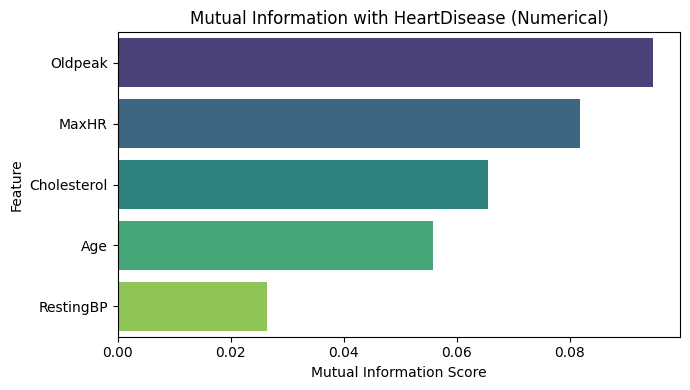

In [ ]:
# Mutual Information to measures the statistical dependency between each feature and target

mi_scores = mutual_info_classif(
    df[numerical_cols],
    df[TARGET],
    discrete_features=False,
    random_state=42
)

mi_series = pd.Series(
    mi_scores,
    index=numerical_cols
).sort_values(ascending=False)

print("Mutual Information Scores (Numerical Features):")
print(mi_series.round(4))

plt.figure(figsize=(7, 4))
sns.barplot(x=mi_series.values, y=mi_series.index, hue=mi_series.index, palette='viridis', legend=False)
plt.xlabel('Mutual Information Score')
plt.ylabel('Feature')
plt.title('Mutual Information with HeartDisease (Numerical)')
plt.tight_layout()
plt.show()

Cramér's V Scores (Categorical Features):
ST_Slope          0.621
ChestPainType     0.538
ExerciseAngina    0.491
Sex               0.301
FastingBS         0.263
RestingECG        0.099
dtype: float64


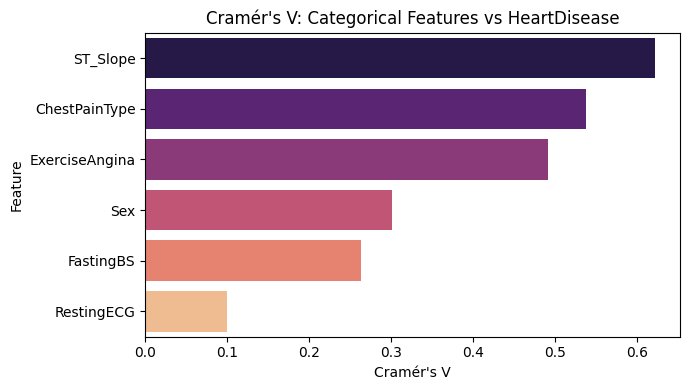

In [ ]:
# Cramér's V measures association between categorical features and target

def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(contingency_table)
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

cramers_results = {}
for col in categorical_cols:
    cramers_results[col] = round(cramers_v(df[col], df[TARGET]), 3)

cramers_series = pd.Series(cramers_results).sort_values(ascending=False)

print("Cramér's V Scores (Categorical Features):")
print(cramers_series)

plt.figure(figsize=(7, 4))
sns.barplot(x=cramers_series.values, y=cramers_series.index, hue=cramers_series.index, palette='magma', legend=False)
plt.xlabel("Cramér's V")
plt.ylabel('Feature')
plt.title("Cramér's V: Categorical Features vs HeartDisease")
plt.tight_layout()
plt.show()

In [28]:
def evaluate_model(model, X_test, y_test, threshold=0.5):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "Accuracy" : accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall"   : recall_score(y_test, y_pred),
        "F1-Score" : f1_score(y_test, y_pred)
    }

## Baseline Model Comparison

Before proceeding with gender-stratified analysis and bias mitigation,
we establish a baseline by comparing 5 candidate models on the full dataset.

This serves two purposes:
1. Identifies the best performing models to carry forward
2. Provides a performance reference point before any fairness interventions

In [ ]:
# 5-Model Baseline Comparison

models_baseline = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest"       : RandomForestClassifier(n_estimators=300, random_state=42),
    "SVM (RBF)"           : SVC(probability=True, random_state=42),
    "Decision Tree"       : DecisionTreeClassifier(
                                max_depth=6,
                                min_samples_split=20,
                                class_weight='balanced',
                                random_state=42
                            ),
    "Gradient Boosting"    : GradientBoostingClassifier(n_estimators=300, random_state=42)                 
}

results = []
for name, model in models_baseline.items():
    model.fit(X_train, y_train)
    metrics = evaluate_model(model, X_test, y_test)
    metrics["Model"] = name
    results.append(metrics)

results_df = pd.DataFrame(results).set_index("Model")
print(results_df.round(2))

                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Logistic Regression      0.89       0.90    0.89      0.90
Random Forest            0.88       0.88    0.91      0.89
SVM (RBF)                0.85       0.86    0.87      0.87
Decision Tree            0.80       0.82    0.82      0.82
Gradient Boosting        0.86       0.89    0.86      0.88


In [ ]:
#Gender Specific model comparison of all 5 baseline models
def gender_wise_metrics(model, X_test, y_test, gender_col="Sex_M", threshold=0.5):
    rows = []
    for gender_value, gender_label in [(0, "Female"), (1, "Male")]:
        idx    = X_test[gender_col] == gender_value
        X_g    = X_test.loc[idx]
        y_g    = y_test.loc[idx]
        y_prob = model.predict_proba(X_g)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)
        rows.append({
            "Gender"   : gender_label,
            "Samples"  : len(y_g),
            "Accuracy" : accuracy_score(y_g, y_pred),
            "Precision": precision_score(y_g, y_pred, zero_division=0),
            "Recall"   : recall_score(y_g, y_pred),
            "F1-score" : f1_score(y_g, y_pred)
        })
    return pd.DataFrame(rows)

all_results = []

for model_name, model in models_baseline.items():
    gender_df= gender_wise_metrics(model, X_test, y_test)
    gender_df["Model"] = model_name
    all_results.append(gender_df)

gender_results = pd.concat(all_results, ignore_index=True)
print("Gender-wise Baseline Performance — All 5 Models:")
print(gender_results.round(2).to_string(index=False))

Gender-wise Baseline Performance — All 5 Models:
Gender  Samples  Accuracy  Precision  Recall  F1-score               Model
Female       38      0.87       0.60    0.50      0.55 Logistic Regression
  Male      146      0.89       0.92    0.92      0.92 Logistic Regression
Female       38      0.92       0.80    0.67      0.73       Random Forest
  Male      146      0.87       0.88    0.93      0.90       Random Forest
Female       38      0.89       0.62    0.83      0.71           SVM (RBF)
  Male      146      0.84       0.88    0.88      0.88           SVM (RBF)
Female       38      0.76       0.36    0.67      0.47       Decision Tree
  Male      146      0.81       0.87    0.83      0.85       Decision Tree
Female       38      0.89       0.67    0.67      0.67   Gradient Boosting
  Male      146      0.86       0.90    0.88      0.89   Gradient Boosting


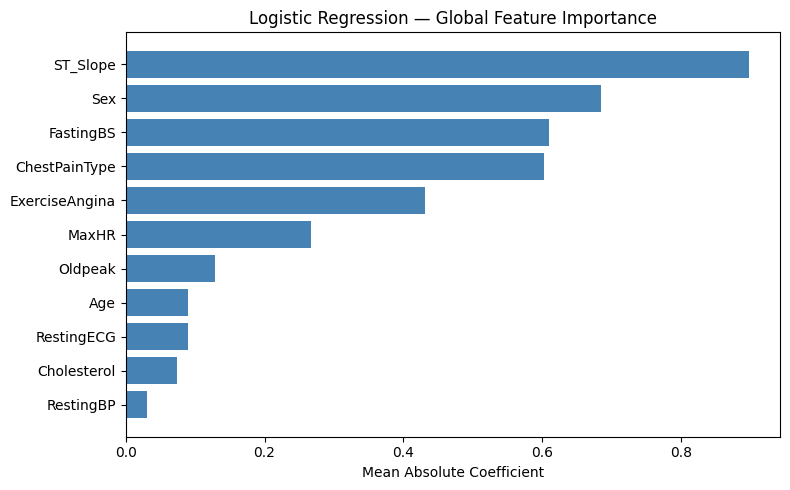

In [ ]:
#Feature importance - Logistic Regression (Global)

lr_global = LogisticRegression(max_iter=1000, solver="liblinear", random_state=42)
lr_global.fit(X_train, y_train)

# Map encoded feature names back to original feature groups
cat_prefixes = ['Sex', 'ChestPainType', 'RestingECG', 
                'ExerciseAngina', 'ST_Slope', 'FastingBS']

coef_df = pd.DataFrame({
    "Feature"    : X_train.columns,
    "Coefficient": lr_global.coef_.flatten()
})

def map_to_original(feature_name, cat_prefixes, numerical_cols):
    if feature_name in numerical_cols:
        return feature_name
    for prefix in cat_prefixes:
        if feature_name.startswith(prefix + "_"):
            return prefix
    return feature_name

coef_df["OriginalFeature"] = coef_df["Feature"].apply(
    lambda x: map_to_original(x, cat_prefixes, numerical_cols)
)

importance_df = (
    coef_df
    .groupby("OriginalFeature")["Coefficient"]
    .apply(lambda x: np.mean(np.abs(x)))
    .reset_index()
    .rename(columns={"Coefficient": "Mean_Abs_Coefficient"})
    .sort_values("Mean_Abs_Coefficient", ascending=True)
)

plt.figure(figsize=(8, 5))
plt.barh(
    importance_df["OriginalFeature"],
    importance_df["Mean_Abs_Coefficient"],
    color="steelblue"
)
plt.xlabel("Mean Absolute Coefficient")
plt.title("Logistic Regression — Global Feature Importance")
plt.tight_layout()
plt.show()

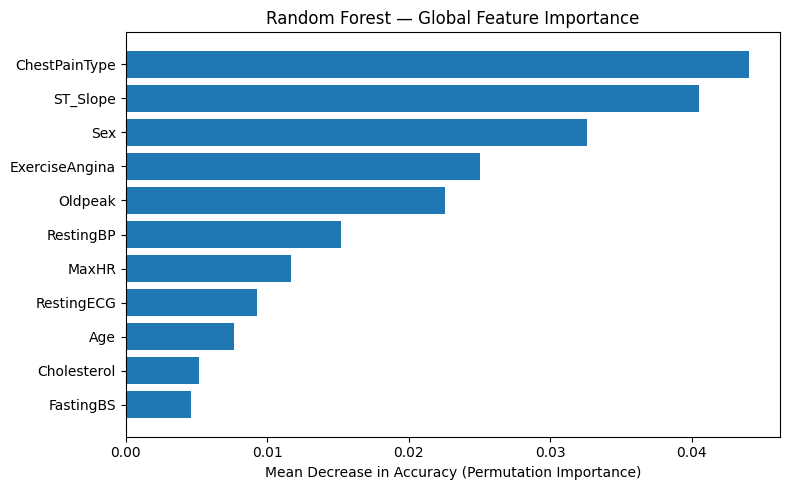

In [ ]:
#Feature importance - Random Forest (Global)

rf_global = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_global.fit(X_train, y_train)

perm_result_rf = permutation_importance(
    rf_global,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

# Map encoded features back to original groups
importance_raw = pd.DataFrame({
    "Feature"   : X_test.columns,
    "Importance": perm_result_rf.importances_mean
})

importance_raw["OriginalFeature"] = importance_raw["Feature"].apply(
    lambda x: map_to_original(x, cat_prefixes, numerical_cols)
)

importance_df_rf = (
    importance_raw
    .groupby("OriginalFeature")["Importance"]
    .sum()
    .reset_index()
    .sort_values("Importance", ascending=True)
)

plt.figure(figsize=(8, 5))
plt.barh(
    importance_df_rf["OriginalFeature"],
    importance_df_rf["Importance"]
)
plt.xlabel("Mean Decrease in Accuracy (Permutation Importance)")
plt.title("Random Forest — Global Feature Importance")
plt.tight_layout()
plt.show()

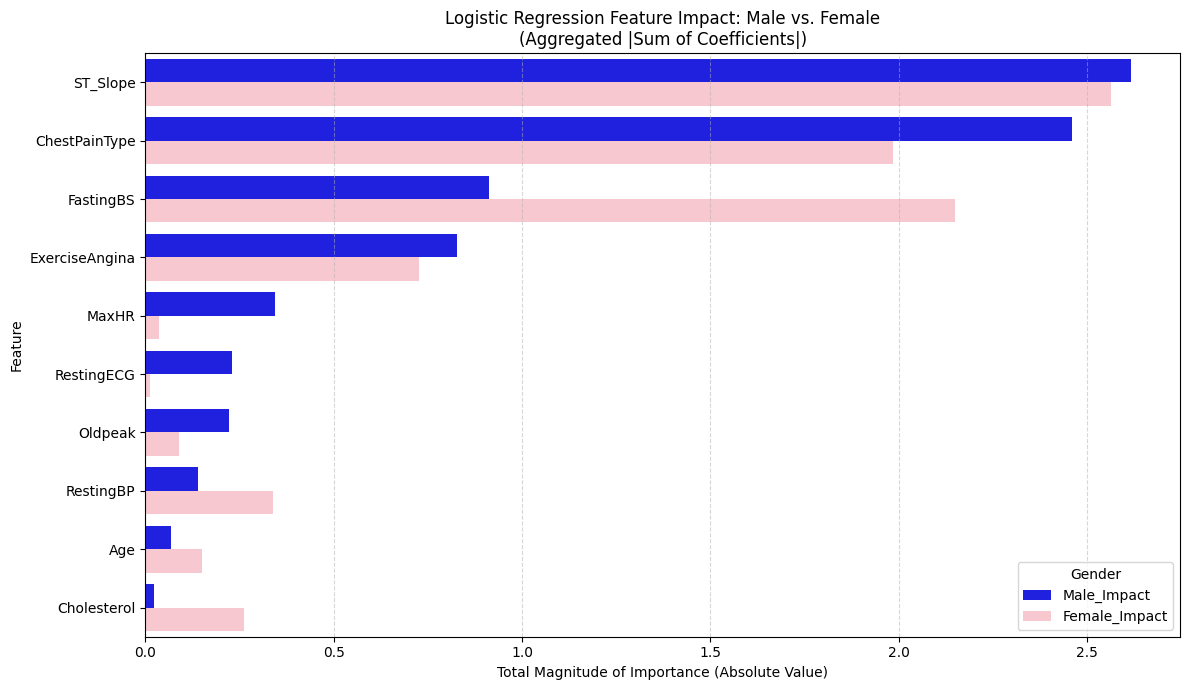

In [ ]:
#Feature Importance Gender wise - Logistic Regression
X_male = X_train[X_train['Sex_M'] == 1]
y_male = y_train[X_train['Sex_M'] == 1]

X_female = X_train[X_train['Sex_M'] == 0]
y_female = y_train[X_train['Sex_M'] == 0]

LogisticRegression_male = LogisticRegression(max_iter=1000, random_state=42)
LogisticRegression_male.fit(X_male, y_male)

LogisticRegression_female = LogisticRegression(max_iter=1000, random_state=42)
LogisticRegression_female.fit(X_female, y_female)

raw_importance_df = pd.DataFrame({
    'Feature'    : X_train.columns,
    'Male_Coef'  : LogisticRegression_male.coef_[0],
    'Female_Coef': LogisticRegression_female.coef_[0]
})

cat_prefixes = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'FastingBS']

male_agg   = {}
female_agg = {}

for index, row in raw_importance_df.iterrows():
    feature_name   = row['Feature']
    parent_feature = feature_name

    for prefix in cat_prefixes:
        if feature_name.startswith(prefix + '_'):
            parent_feature = prefix
            break

    male_agg[parent_feature]   = male_agg.get(parent_feature, 0) + abs(row['Male_Coef'])
    female_agg[parent_feature] = female_agg.get(parent_feature, 0) + abs(row['Female_Coef'])

grouped_df = pd.DataFrame({
    'Feature'      : male_agg.keys(),
    'Male_Impact'  : male_agg.values(),
    'Female_Impact': [female_agg[k] for k in male_agg.keys()]
})

grouped_df = grouped_df[grouped_df['Feature'] != 'Sex']
grouped_df = grouped_df.sort_values(by='Male_Impact', ascending=False)
plot_data  = grouped_df.melt(id_vars='Feature', var_name='Gender', value_name='Impact')

plt.figure(figsize=(12, 7))
sns.barplot(
    data=plot_data,
    x='Impact',
    y='Feature',
    hue='Gender',
    palette={'Male_Impact': 'blue', 'Female_Impact': 'pink'}
)

plt.title('Logistic Regression Feature Impact: Male vs. Female\n(Aggregated |Sum of Coefficients|)')
plt.xlabel('Total Magnitude of Importance (Absolute Value)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

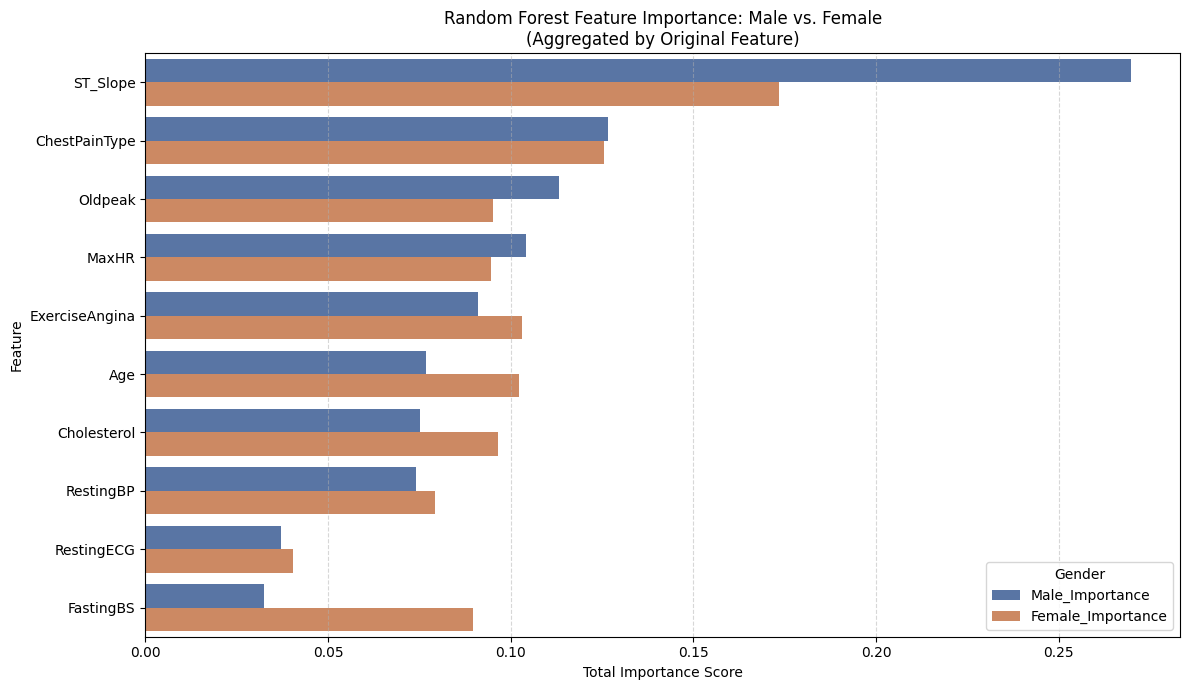

In [ ]:
#Feature Importance Gender wise - Random Forest
X_male = X_train[X_train['Sex_M'] == 1]
y_male = y_train[X_train['Sex_M'] == 1]

X_female = X_train[X_train['Sex_M'] == 0]
y_female = y_train[X_train['Sex_M'] == 0]

model_male = RandomForestClassifier(n_estimators=100, random_state=42)
model_male.fit(X_male, y_male)

model_female = RandomForestClassifier(n_estimators=100, random_state=42)
model_female.fit(X_female, y_female)

raw_importance_df = pd.DataFrame({
    'Feature'   : X_train.columns,
    'Male_Raw'  : model_male.feature_importances_,
    'Female_Raw': model_female.feature_importances_
})

cat_prefixes = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'FastingBS']

male_agg   = {}
female_agg = {}

for index, row in raw_importance_df.iterrows():
    feature_name   = row['Feature']
    parent_feature = feature_name

    for prefix in cat_prefixes:
        if feature_name.startswith(prefix + '_'):
            parent_feature = prefix
            break

    male_agg[parent_feature]   = male_agg.get(parent_feature, 0) + row['Male_Raw']
    female_agg[parent_feature] = female_agg.get(parent_feature, 0) + row['Female_Raw']

grouped_df = pd.DataFrame({
    'Feature'           : male_agg.keys(),
    'Male_Importance'   : male_agg.values(),
    'Female_Importance' : [female_agg[k] for k in male_agg.keys()]
})

grouped_df = grouped_df[grouped_df['Feature'] != 'Sex']
grouped_df = grouped_df.sort_values(by='Male_Importance', ascending=False)
plot_data  = grouped_df.melt(id_vars='Feature', var_name='Gender', value_name='Importance')

plt.figure(figsize=(12, 7))
sns.barplot(
    data=plot_data,
    x='Importance',
    y='Feature',
    hue='Gender',
    palette={'Male_Importance': '#4C72B0', 'Female_Importance': '#DD8452'}
)

plt.title('Random Forest Feature Importance: Male vs. Female\n(Aggregated by Original Feature)')
plt.xlabel('Total Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

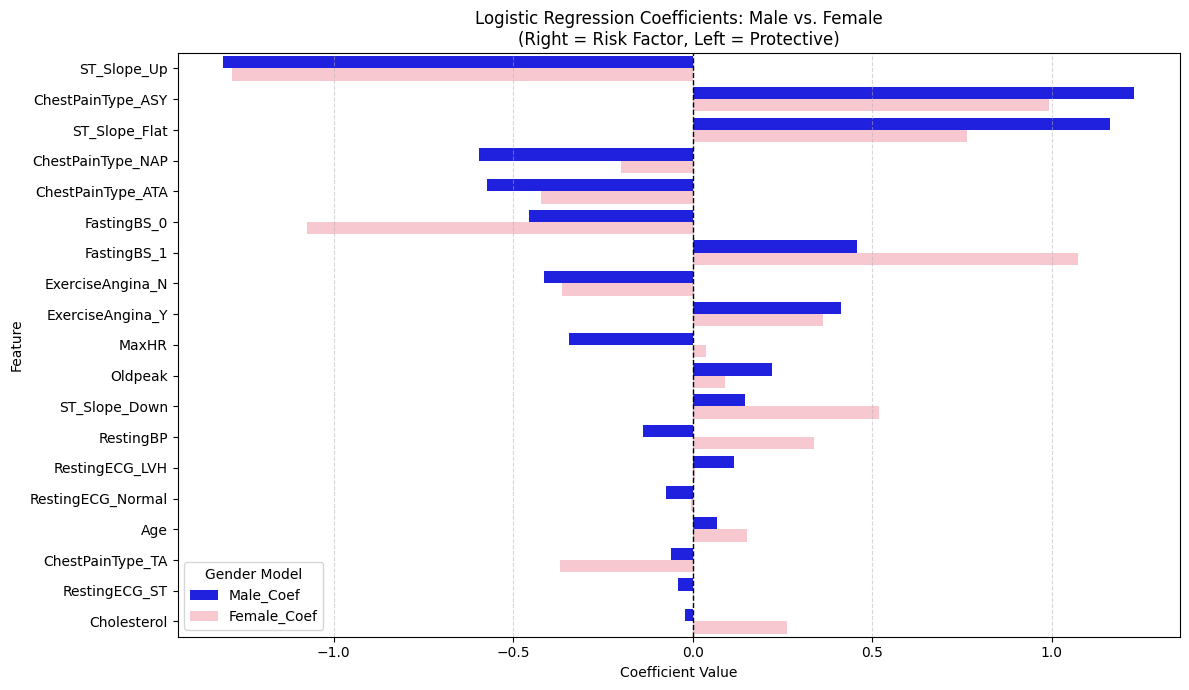

Top 10 Features by Gender Coefficients:
              Feature  Male_Coef  Female_Coef
18        ST_Slope_Up  -1.308259    -1.282588
8   ChestPainType_ASY   1.229992     0.992281
17      ST_Slope_Flat   1.161746     0.764108
10  ChestPainType_NAP  -0.595436    -0.200249
9   ChestPainType_ATA  -0.574192    -0.422995
14        FastingBS_0  -0.456947    -1.074563
15        FastingBS_1   0.456170     1.074015
12   ExerciseAngina_N  -0.413420    -0.363843
13   ExerciseAngina_Y   0.412642     0.363295
3               MaxHR  -0.344425     0.037356


In [35]:
#Sub-feature importance gender wise - Logistic regression
X_male = X_train[X_train['Sex_M'] == 1]
y_male = y_train[X_train['Sex_M'] == 1]

X_female = X_train[X_train['Sex_M'] == 0]
y_female = y_train[X_train['Sex_M'] == 0]

LogisticRegression_male = LogisticRegression(max_iter=1000, random_state=42)
LogisticRegression_male.fit(X_male, y_male)

LogisticRegression_female = LogisticRegression(max_iter=1000, random_state=42)
LogisticRegression_female.fit(X_female, y_female)

importance_df = pd.DataFrame({
    'Feature'      : X_train.columns,
    'Male_Coef'    : LogisticRegression_male.coef_[0],
    'Female_Coef'  : LogisticRegression_female.coef_[0],
    'Abs_Male_Coef': abs(LogisticRegression_male.coef_[0])
})

importance_df = importance_df[~importance_df['Feature'].str.startswith('Sex')]
importance_df = importance_df.sort_values(by='Abs_Male_Coef', ascending=False)

plot_data = importance_df.head(100).melt(
    id_vars='Feature',
    value_vars=['Male_Coef', 'Female_Coef'],
    var_name='Gender',
    value_name='Coefficient'
)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=plot_data,
    x='Coefficient',
    y='Feature',
    hue='Gender',
    palette={'Male_Coef': 'blue', 'Female_Coef': 'pink'}
)

plt.title('Logistic Regression Coefficients: Male vs. Female\n(Right = Risk Factor, Left = Protective)')
plt.xlabel('Coefficient Value')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend(title='Gender Model')
plt.tight_layout()
plt.show()

print("Top 10 Features by Gender Coefficients:")
print(importance_df[['Feature', 'Male_Coef', 'Female_Coef']].head(10))

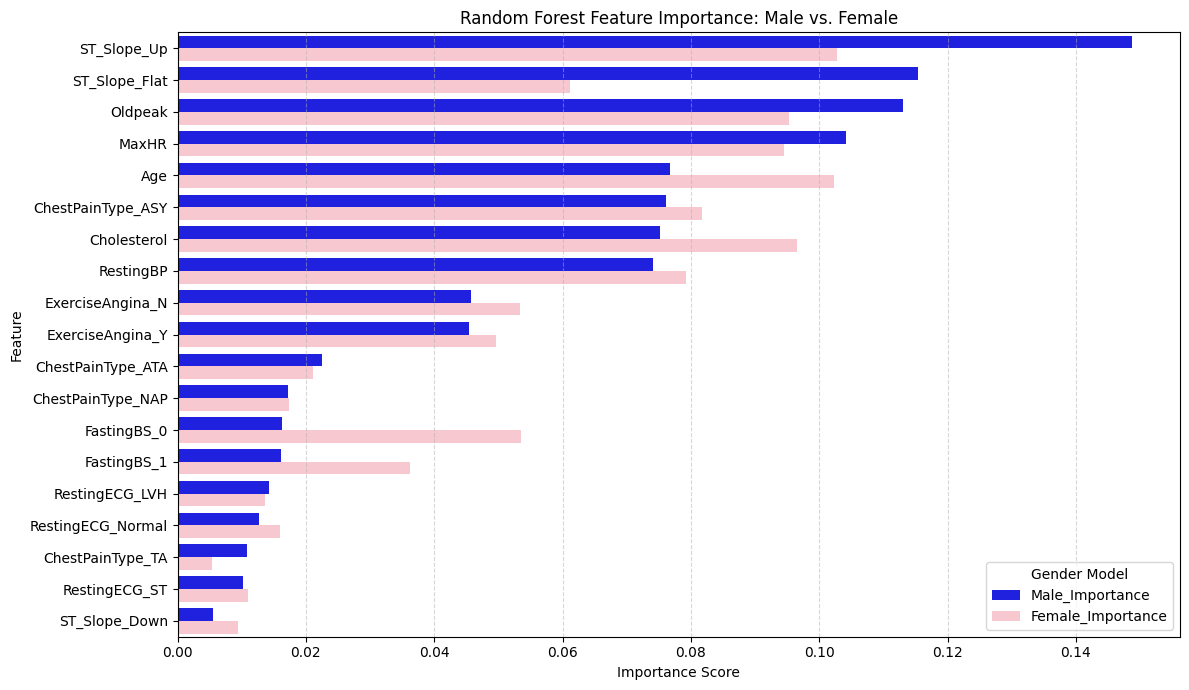

Top 10 Features by Gender Importance:
              Feature  Male_Importance  Female_Importance
18        ST_Slope_Up         0.148773           0.102807
17      ST_Slope_Flat         0.115386           0.061229
4             Oldpeak         0.113080           0.095208
3               MaxHR         0.104113           0.094468
0                 Age         0.076710           0.102341
8   ChestPainType_ASY         0.076135           0.081756
2         Cholesterol         0.075115           0.096581
1           RestingBP         0.074134           0.079297
12   ExerciseAngina_N         0.045716           0.053323
13   ExerciseAngina_Y         0.045362           0.049638


In [36]:
#Sub-feature importance gender wise - Random Forest
X_male = X_train[X_train['Sex_M'] == 1]
y_male = y_train[X_train['Sex_M'] == 1]

X_female = X_train[X_train['Sex_M'] == 0]
y_female = y_train[X_train['Sex_M'] == 0]

model_male = RandomForestClassifier(n_estimators=100, random_state=42)
model_male.fit(X_male, y_male)

model_female = RandomForestClassifier(n_estimators=100, random_state=42)
model_female.fit(X_female, y_female)

importance_df = pd.DataFrame({
    'Feature'          : X_train.columns,
    'Male_Importance'  : model_male.feature_importances_,
    'Female_Importance': model_female.feature_importances_
})

importance_df = importance_df[~importance_df['Feature'].str.startswith('Sex')]
importance_df = importance_df.sort_values(by='Male_Importance', ascending=False)

plot_data = importance_df.head(100).melt(id_vars='Feature', var_name='Gender', value_name='Importance')

plt.figure(figsize=(12, 7))
sns.barplot(
    data=plot_data,
    x='Importance',
    y='Feature',
    hue='Gender',
    palette={'Male_Importance': 'blue', 'Female_Importance': 'pink'}
)

plt.title('Random Forest Feature Importance: Male vs. Female')
plt.xlabel('Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend(title='Gender Model')
plt.tight_layout()
plt.show()

print("Top 10 Features by Gender Importance:")
print(importance_df.head(10))


In [37]:
# Bias Mitigation
### Random Sampling

X_female = X_train[X_train['Sex_M'] == 0]
y_female = y_train[X_train['Sex_M'] == 0]

X_male = X_train[X_train['Sex_M'] == 1]
y_male = y_train[X_train['Sex_M'] == 1]

count_male   = len(X_male)
count_female = len(X_female)
n_to_add     = count_male - count_female

print(f"--- Original Training Data ---")
print(f"Men: {count_male}")
print(f"Women: {count_female}")
print(f"Gap: {n_to_add} missing female samples.")

if n_to_add > 0:
    print(f"\nGenerating {n_to_add} synthetic female samples...")

    synthetic_X = X_female.sample(n=n_to_add, replace=True, random_state=42)
    synthetic_y = y_female.loc[synthetic_X.index]

    numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

    for col in numerical_cols:
        if col in synthetic_X.columns:
            std_dev = synthetic_X[col].std()
            noise   = np.random.normal(0, std_dev * 0.05, size=len(synthetic_X))
            synthetic_X[col] = synthetic_X[col] + noise

    X_train_balanced = pd.concat([X_train, synthetic_X], axis=0)
    y_train_balanced = pd.concat([y_train, synthetic_y], axis=0)

    print(f"Done. New Training Count: {len(X_train_balanced)} rows.")

else:
    print("\nData is already balanced. No synthetic data needed.")
    X_train_balanced = X_train
    y_train_balanced = y_train

--- Original Training Data ---
Men: 579
Women: 155
Gap: 424 missing female samples.

Generating 424 synthetic female samples...
Done. New Training Count: 1158 rows.


In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, recall_score

lr = LogisticRegression(max_iter=1000, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

lr.fit(X_train_balanced, y_train_balanced)
rf.fit(X_train_balanced, y_train_balanced)

y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

In [39]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

def evaluate_group(model_name, y_true, y_pred, mask, group_name):
    print(f"\n--- {model_name} | {group_name} ---")
    print("Accuracy :", accuracy_score(y_true[mask], y_pred[mask]))
    print("Recall   :", recall_score(y_true[mask], y_pred[mask]))
    print("Precision:", precision_score(y_true[mask], y_pred[mask], zero_division=0))
    print("F1-score :", f1_score(y_true[mask], y_pred[mask]))

male_mask   = X_test["Sex_M"] == 1
female_mask = X_test["Sex_M"] == 0

print("=== Logistic Regression (Overall) ===")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("F1-score :", f1_score(y_test, y_pred_lr))

evaluate_group("Logistic Regression", y_test, y_pred_lr, male_mask,   "Male")
evaluate_group("Logistic Regression", y_test, y_pred_lr, female_mask, "Female")

print("\n=== Random Forest (Overall) ===")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("F1-score :", f1_score(y_test, y_pred_rf))

evaluate_group("Random Forest", y_test, y_pred_rf, male_mask,   "Male")
evaluate_group("Random Forest", y_test, y_pred_rf, female_mask, "Female")

=== Logistic Regression (Overall) ===
Accuracy : 0.8695652173913043
Recall   : 0.8823529411764706
Precision: 0.8823529411764706
F1-score : 0.8823529411764706

--- Logistic Regression | Male ---
Accuracy : 0.863013698630137
Recall   : 0.8958333333333334
Precision: 0.8958333333333334
F1-score : 0.8958333333333334

--- Logistic Regression | Female ---
Accuracy : 0.8947368421052632
Recall   : 0.6666666666666666
Precision: 0.6666666666666666
F1-score : 0.6666666666666666

=== Random Forest (Overall) ===
Accuracy : 0.8858695652173914
Recall   : 0.9117647058823529
Precision: 0.8857142857142857
F1-score : 0.8985507246376812

--- Random Forest | Male ---
Accuracy : 0.8767123287671232
Recall   : 0.9270833333333334
Precision: 0.89
F1-score : 0.9081632653061225

--- Random Forest | Female ---
Accuracy : 0.9210526315789473
Recall   : 0.6666666666666666
Precision: 0.8
F1-score : 0.7272727272727273


### SMOTE

In [40]:
!pip install imbalanced-learn

In [41]:
from imblearn.over_sampling import SMOTE
import pandas as pd

sex_col = [col for col in X_train.columns if col.startswith("Sex_")][1]

X_male = X_train[X_train[sex_col] == True]
y_male = y_train.loc[X_male.index]

X_female = X_train[X_train[sex_col] == False]
y_female = y_train.loc[X_female.index]

print("--- Original Distribution ---")
print("\nFemale target distribution:")
print(y_female.value_counts())

print("\nMale target distribution:")
print(y_male.value_counts())

smote = SMOTE(random_state=42, k_neighbors=5)

X_female_smote, y_female_smote = smote.fit_resample(X_female, y_female)

print("\n--- After SMOTE (Female Only) ---")
print(pd.Series(y_female_smote).value_counts())

X_train_balanced = pd.concat([X_male, pd.DataFrame(X_female_smote, columns=X_female.columns)], axis=0)
y_train_balanced = pd.concat([y_male, pd.Series(y_female_smote)], axis=0)

X_train_balanced = X_train_balanced.reset_index(drop=True)
y_train_balanced = y_train_balanced.reset_index(drop=True)

shuffled_idx = X_train_balanced.sample(frac=1, random_state=42).index

X_train_balanced = X_train_balanced.loc[shuffled_idx].reset_index(drop=True)
y_train_balanced = y_train_balanced.loc[shuffled_idx].reset_index(drop=True)

print("\n--- Final Combined Distribution ---")
print(y_train_balanced.value_counts())

print(f"\nFinal Training Size: {len(X_train_balanced)}")

--- Original Distribution ---

Female target distribution:
HeartDisease
0    111
1     44
Name: count, dtype: int64

Male target distribution:
HeartDisease
1    362
0    217
Name: count, dtype: int64

--- After SMOTE (Female Only) ---
HeartDisease
1    111
0    111
Name: count, dtype: int64

--- Final Combined Distribution ---
HeartDisease
1    473
0    328
Name: count, dtype: int64

Final Training Size: 801


In [42]:
#Training and Evaluation after SMOTE
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

lr = LogisticRegression(max_iter=2000)
rf = RandomForestClassifier(random_state=42)

lr.fit(X_train_balanced, y_train_balanced)
rf.fit(X_train_balanced, y_train_balanced)

X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

X_test_df = pd.DataFrame(X_test, columns=X_train.columns)

male_col = 'Sex_M'

male_mask   = X_test_df[male_col] == 1
X_test_male   = X_test_df[male_mask]
X_test_female = X_test_df[~male_mask]

y_test_male   = y_test[male_mask]
y_test_female = y_test[~male_mask]

def evaluate(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, zero_division=0),
        recall_score(y_true, y_pred, zero_division=0),
        f1_score(y_true, y_pred, zero_division=0)
    ]

results = pd.DataFrame([
    ["LR_Male",   *evaluate(y_test_male,   lr.predict(X_test_male))],
    ["LR_Female", *evaluate(y_test_female, lr.predict(X_test_female))],
    ["RF_Male",   *evaluate(y_test_male,   rf.predict(X_test_male))],
    ["RF_Female", *evaluate(y_test_female, rf.predict(X_test_female))]
],
columns=["Group", "Accuracy", "Precision", "Recall", "F1"])

print("\n---  Gender-wise Model Performance (Female-SMOTE) ---")
print(results)


---  Gender-wise Model Performance (Female-SMOTE) ---
       Group  Accuracy  Precision    Recall        F1
0    LR_Male  0.883562   0.915789  0.906250  0.910995
1  LR_Female  0.894737   0.625000  0.833333  0.714286
2    RF_Male  0.849315   0.877551  0.895833  0.886598
3  RF_Female  0.921053   0.714286  0.833333  0.769231


In [43]:
pushing_cols = [c for c in X_train_balanced.columns
                if c in ['Age', 'Cholesterol']
                or c.startswith('ST_Slope')
                or c.startswith('FastingBS')]

if 'FastingBS' not in pushing_cols and 'FastingBS' in X_train_balanced.columns:
    pushing_cols = ['FastingBS'] + pushing_cols

top4_cols = [c for c in X_train_balanced.columns
             if c in ['FastingBS']
             or c.startswith('ChestPainType')
             or c.startswith('ExerciseAngina')
             or c.startswith('ST_Slope')]

X_train_p = X_train_balanced[pushing_cols]
X_test_p  = X_test.reindex(columns=pushing_cols, fill_value=0)

X_train_t = X_train_balanced[top4_cols]
X_test_t  = X_test.reindex(columns=top4_cols, fill_value=0)

lr_p = LogisticRegression(max_iter=2000, random_state=42)
rf_p = RandomForestClassifier(random_state=42)

lr_t = LogisticRegression(max_iter=2000, random_state=42)
rf_t = RandomForestClassifier(random_state=42)

lr_p.fit(X_train_p, y_train_balanced)
rf_p.fit(X_train_p, y_train_balanced)

lr_t.fit(X_train_t, y_train_balanced)
rf_t.fit(X_train_t, y_train_balanced)

X_test   = X_test.reset_index(drop=True)
X_test_p = X_test_p.reset_index(drop=True)
X_test_t = X_test_t.reset_index(drop=True)
y_test   = y_test.reset_index(drop=True)

male_mask = (X_test['Sex_M'] == 1).values

X_test_p_male   = X_test_p[male_mask]
X_test_p_female = X_test_p[~male_mask]

X_test_t_male   = X_test_t[male_mask]
X_test_t_female = X_test_t[~male_mask]

y_test_male   = y_test[male_mask]
y_test_female = y_test[~male_mask]

def evaluate(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, zero_division=0),
        recall_score(y_true, y_pred, zero_division=0),
        f1_score(y_true, y_pred, zero_division=0)
    ]

results = pd.DataFrame([
    ["Pushing4_LR_Male",   *evaluate(y_test_male,   lr_p.predict(X_test_p_male))],
    ["Pushing4_LR_Female", *evaluate(y_test_female, lr_p.predict(X_test_p_female))],
    ["Pushing4_RF_Male",   *evaluate(y_test_male,   rf_p.predict(X_test_p_male))],
    ["Pushing4_RF_Female", *evaluate(y_test_female, rf_p.predict(X_test_p_female))],
    ["Top4_LR_Male",       *evaluate(y_test_male,   lr_t.predict(X_test_t_male))],
    ["Top4_LR_Female",     *evaluate(y_test_female, lr_t.predict(X_test_t_female))],
    ["Top4_RF_Male",       *evaluate(y_test_male,   rf_t.predict(X_test_t_male))],
    ["Top4_RF_Female",     *evaluate(y_test_female, rf_t.predict(X_test_t_female))]
],
columns=["Group", "Accuracy", "Precision", "Recall", "F1"])

print("\n--- Pushing-4 & Top-4 (Female-SMOTE) ---")
print(results)


--- Pushing-4 & Top-4 (Female-SMOTE) ---
                Group  Accuracy  Precision    Recall        F1
0    Pushing4_LR_Male  0.773973   0.862069  0.781250  0.819672
1  Pushing4_LR_Female  0.684211   0.312500  0.833333  0.454545
2    Pushing4_RF_Male  0.787671   0.835052  0.843750  0.839378
3  Pushing4_RF_Female  0.684211   0.312500  0.833333  0.454545
4        Top4_LR_Male  0.849315   0.911111  0.854167  0.881720
5      Top4_LR_Female  0.815789   0.461538  1.000000  0.631579
6        Top4_RF_Male  0.842466   0.884211  0.875000  0.879581
7      Top4_RF_Female  0.736842   0.375000  1.000000  0.545455


In [ ]:
# Pushing 4 predictions
lr_p_all = lr_p.predict(X_test_p)
rf_p_all = rf_p.predict(X_test_p)

# Top 4 predictions
lr_t_all = lr_t.predict(X_test_t)
rf_t_all = rf_t.predict(X_test_t)

def evaluate(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, zero_division=0),
        recall_score(y_true, y_pred, zero_division=0),
        f1_score(y_true, y_pred, zero_division=0)
    ]

total_results = pd.DataFrame([
    ["Pushing4_LR_Total", *evaluate(y_test, lr_p_all)],
    ["Pushing4_RF_Total", *evaluate(y_test, rf_p_all)],
    ["Top4_LR_Total",     *evaluate(y_test, lr_t_all)],
    ["Top4_RF_Total",     *evaluate(y_test, rf_t_all)]
],
columns=["Model", "Accuracy", "Precision", "Recall", "F1"])

print("\n--- Pushing-4 & Top-4 (Female-SMOTE) - total dataset---")
print(total_results)


--- Pushing-4 & Top-4 (Female-SMOTE) - total dataset---
               Model  Accuracy  Precision    Recall        F1
0  Pushing4_LR_Total  0.755435   0.776699  0.784314  0.780488
1  Pushing4_RF_Total  0.766304   0.761062  0.843137  0.800000
2      Top4_LR_Total  0.842391   0.854369  0.862745  0.858537
3      Top4_RF_Total  0.820652   0.810811  0.882353  0.845070


In [45]:
### Fairness Aware Reweighting
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, recall_score

# Masks
female_mask = X_test['Sex_F'] == 1
male_mask   = X_test['Sex_F'] == 0

lr_base = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    solver='liblinear'
)

rf_base = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42
)

lr_base.fit(X_train, y_train)
rf_base.fit(X_train, y_train)

y_pred_lr_base = lr_base.predict(X_test)
y_pred_rf_base = rf_base.predict(X_test)

# Female Recall
lr_base_recall_female = recall_score(y_test[female_mask], y_pred_lr_base[female_mask])
rf_base_recall_female = recall_score(y_test[female_mask], y_pred_rf_base[female_mask])

# Male Recall
lr_base_recall_male = recall_score(y_test[male_mask], y_pred_lr_base[male_mask])
rf_base_recall_male = recall_score(y_test[male_mask], y_pred_rf_base[male_mask])

print("WEIGHTED MODELS (Female Boost)")

sample_weight = np.ones(len(y_train))
boost_factor  = 3

mask = (X_train['Sex_F'] == 1) & (y_train == 1)
sample_weight[mask] = boost_factor

print("Boosted Female + Disease samples:", mask.sum())

lr_weighted = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    solver='liblinear'
)

rf_weighted = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42
)

lr_weighted.fit(X_train, y_train, sample_weight=sample_weight)
rf_weighted.fit(X_train, y_train, sample_weight=sample_weight)

y_pred_lr_weighted = lr_weighted.predict(X_test)
y_pred_rf_weighted = rf_weighted.predict(X_test)

# Female Recall
lr_weighted_recall_female = recall_score(y_test[female_mask], y_pred_lr_weighted[female_mask])
rf_weighted_recall_female = recall_score(y_test[female_mask], y_pred_rf_weighted[female_mask])

# Male Recall
lr_weighted_recall_male = recall_score(y_test[male_mask], y_pred_lr_weighted[male_mask])
rf_weighted_recall_male = recall_score(y_test[male_mask], y_pred_rf_weighted[male_mask])

print("\nRECALL COMPARISON (FEMALE vs MALE)")
print(f"Logistic Regression Female Recall: AFTER = {lr_weighted_recall_female:.4f}")
print(f"Logistic Regression Male Recall: AFTER = {lr_weighted_recall_male:.4f}")
print(f"\nRandom Forest Female Recall: AFTER = {rf_weighted_recall_female:.4f}")
print(f"Random Forest Male Recall:  AFTER = {rf_weighted_recall_male:.4f}")

WEIGHTED MODELS (Female Boost)
Boosted Female + Disease samples: 44

RECALL COMPARISON (FEMALE vs MALE)
Logistic Regression Female Recall: AFTER = 0.8333
Logistic Regression Male Recall: AFTER = 0.8646

Random Forest Female Recall: AFTER = 0.8333
Random Forest Male Recall:  AFTER = 0.9167


In [ ]:
### Exponentiated Gradient - Demographic Parity

from fairlearn.reductions import ExponentiatedGradient, DemographicParity
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score
import pandas as pd
import numpy as np

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest"      : RandomForestClassifier(n_estimators=300, random_state=42)
}

def gender_metrics_dp(model, X_test, y_test, gender_col="Sex_M"):
    results = {}
    for val, label in [(0, "Female"), (1, "Male")]:
        idx    = X_test[gender_col] == val
        X_g    = X_test.loc[idx]
        y_g    = y_test.loc[idx]
        y_pred = model.predict(X_g)
        results[label] = {
            "Accuracy"     : accuracy_score(y_g, y_pred),
            "Recall"       : recall_score(y_g, y_pred),
            "Positive Rate": np.mean(y_pred)
        }

    # Equal Opportunity Gap
    eo_gap = abs(results["Female"]["Recall"] - results["Male"]["Recall"])

    # Demographic Parity Gap
    dp_gap = abs(results["Female"]["Positive Rate"] - results["Male"]["Positive Rate"])

    return results, eo_gap, dp_gap

rows       = []
A_train    = X_train["Sex_M"]
A_test     = X_test["Sex_M"]

for name, base_model in models.items():

    # ── BASELINE ──────────────────────────────────────────────────────────────
    base_model.fit(X_train, y_train)
    base_res, base_eo, base_dp = gender_metrics_dp(base_model, X_test, y_test)

    # ── FAIRLEARN MODEL ───────────────────────────────────────────────────────
    mitigator = ExponentiatedGradient(
        estimator=base_model,
        constraints=DemographicParity()
    )
    mitigator.fit(X_train, y_train, sensitive_features=A_train)
    fair_res, fair_eo, fair_dp = gender_metrics_dp(mitigator, X_test, y_test)

    rows.append({
        "Model"         : name,
        "Type"          : "Baseline",
        "Female Recall" : base_res["Female"]["Recall"],
        "Male Recall"   : base_res["Male"]["Recall"],
        "EO Gap"        : base_eo,
        "DP Gap"        : base_dp
    })
    rows.append({
        "Model"         : name,
        "Type"          : "Fairlearn (DP)",
        "Female Recall" : fair_res["Female"]["Recall"],
        "Male Recall"   : fair_res["Male"]["Recall"],
        "EO Gap"        : fair_eo,
        "DP Gap"        : fair_dp
    })

dp_results = pd.DataFrame(rows)
print("Exponentiated Gradient — Demographic Parity Results:")
print(dp_results.round(3).to_string(index=False))

Exponentiated Gradient — Demographic Parity Results:
              Model           Type  Female Recall  Male Recall  EO Gap  DP Gap
Logistic Regression       Baseline          0.500        0.917   0.417   0.526
Logistic Regression Fairlearn (DP)          1.000        0.844   0.156   0.050
      Random Forest       Baseline          0.667        0.927   0.260   0.560
      Random Forest Fairlearn (DP)          1.000        0.927   0.073   0.113


In [ ]:
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
import pandas as pd
import numpy as np

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest"      : RandomForestClassifier(n_estimators=300, random_state=42)
}

def gender_metrics_eo(model, X_test, y_test, gender_col="Sex_M"):
    results = {}
    for val, label in [(0, "Female"), (1, "Male")]:
        idx    = X_test[gender_col] == val
        X_g    = X_test.loc[idx]
        y_g    = y_test.loc[idx]
        y_pred = model.predict(X_g)

        tn, fp, fn, tp = confusion_matrix(y_g, y_pred).ravel()

        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

        results[label] = {
            "Recall (TPR)": tpr,
            "FPR"         : fpr
        }

    tpr_gap = abs(results["Female"]["Recall (TPR)"] - results["Male"]["Recall (TPR)"])
    fpr_gap = abs(results["Female"]["FPR"] - results["Male"]["FPR"])

    return results, tpr_gap, fpr_gap

rows    = []
A_train = X_train["Sex_M"]

for name, base_model in models.items():

    # ── BASELINE ──────────────────────────────────────────────────────────────
    base_model.fit(X_train, y_train)
    base_res, base_tpr_gap, base_fpr_gap = gender_metrics_eo(
        base_model, X_test, y_test
    )

    # ── FAIRLEARN MODEL ───────────────────────────────────────────────────────
    mitigator = ExponentiatedGradient(
        estimator=base_model,
        constraints=EqualizedOdds()
    )
    mitigator.fit(X_train, y_train, sensitive_features=A_train)
    fair_res, fair_tpr_gap, fair_fpr_gap = gender_metrics_eo(
        mitigator, X_test, y_test
    )

    rows.append({
        "Model"        : name,
        "Type"         : "Baseline",
        "Female Recall": base_res["Female"]["Recall (TPR)"],
        "Male Recall"  : base_res["Male"]["Recall (TPR)"],
        "TPR Gap"      : base_tpr_gap,
        "FPR Gap"      : base_fpr_gap
    })
    rows.append({
        "Model"        : name,
        "Type"         : "Fairlearn (EO)",
        "Female Recall": fair_res["Female"]["Recall (TPR)"],
        "Male Recall"  : fair_res["Male"]["Recall (TPR)"],
        "TPR Gap"      : fair_tpr_gap,
        "FPR Gap"      : fair_fpr_gap
    })

eo_results = pd.DataFrame(rows)
print("Exponentiated Gradient — Equalized Odds Results:")
print(eo_results.round(3).to_string(index=False))

Exponentiated Gradient — Equalized Odds Results:
              Model           Type  Female Recall  Male Recall  TPR Gap  FPR Gap
Logistic Regression       Baseline          0.500        0.917    0.417    0.098
Logistic Regression Fairlearn (EO)          0.833        0.875    0.042    0.066
      Random Forest       Baseline          0.667        0.927    0.260    0.209
      Random Forest Fairlearn (EO)          0.667        0.938    0.271    0.209


In [48]:
# AIF360 style reweighting for selected clinical protected features

X_train_rw = X_train.copy()

# Define binary protected feature flags
X_train_rw['prot_FastingBS']   = X_train_rw['FastingBS_1']
X_train_rw['prot_MaxHR']       = (X_train_rw['MaxHR'] < X_train_rw['MaxHR'].median()).astype(int)
X_train_rw['prot_RestingBP']   = (X_train_rw['RestingBP'] >= X_train_rw['RestingBP'].quantile(0.75)).astype(int)
X_train_rw['prot_Cholesterol'] = (X_train_rw['Cholesterol'] >= X_train_rw['Cholesterol'].quantile(0.75)).astype(int)
X_train_rw['prot_RestingECG']  = X_train_rw['RestingECG_ST'].astype(int) if 'RestingECG_ST' in X_train_rw.columns else (X_train_rw['RestingECG_Normal'] == 0).astype(int)

protected_features = [
    'prot_FastingBS',
    'prot_MaxHR',
    'prot_RestingBP',
    'prot_Cholesterol',
    'prot_RestingECG'
]

def compute_reweighting(df, label_col, protected_col):
    weights = np.zeros(len(df))
    for a in [0, 1]:
        for y in [0, 1]:
            mask = (df[protected_col] == a) & (df[label_col] == y)
            P_a  = (df[protected_col] == a).mean()
            P_y  = (df[label_col] == y).mean()
            P_ay = mask.mean()
            if P_ay > 0:
                weights[mask] = (P_a * P_y) / P_ay
    return weights

train_df_full               = X_train_rw.copy()
train_df_full['HeartDisease'] = y_train

combined_weights = np.ones(len(train_df_full))
for prot in protected_features:
    combined_weights *= compute_reweighting(train_df_full, 'HeartDisease', prot)

print("Reweighting completed.")
print(f"Weight range: {combined_weights.min():.3f} — {combined_weights.max():.3f}")

models_aif = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest"      : RandomForestClassifier(n_estimators=300, random_state=42)
}

def gender_metrics_aif(model, X_test, y_test, gender_col="Sex_M"):
    results = {}
    for gender_value, gender_label in [(0, "Female"), (1, "Male")]:
        idx    = X_test[gender_col] == gender_value
        X_g    = X_test.loc[idx]
        y_g    = y_test.loc[idx]
        y_pred = model.predict(X_g)
        results[gender_label] = {
            "Accuracy": accuracy_score(y_g, y_pred),
            "Recall"  : recall_score(y_g, y_pred)
        }
    gap = abs(results["Female"]["Recall"] - results["Male"]["Recall"])
    return results, gap

final_rows = []

for model_name, model in models_aif.items():

    # Baseline
    model.fit(X_train, y_train)
    base_results, base_gap = gender_metrics_aif(model, X_test, y_test)

    # Reweighted
    model.fit(X_train, y_train, sample_weight=combined_weights)
    rw_results, rw_gap = gender_metrics_aif(model, X_test, y_test)

    final_rows.append({
        "Model"                : model_name,
        "Type"                 : "Baseline",
        "Female Recall"        : base_results["Female"]["Recall"],
        "Male Recall"          : base_results["Male"]["Recall"],
        "Equal Opportunity Gap": base_gap
    })
    final_rows.append({
        "Model"                : model_name,
        "Type"                 : "Reweighted",
        "Female Recall"        : rw_results["Female"]["Recall"],
        "Male Recall"          : rw_results["Male"]["Recall"],
        "Equal Opportunity Gap": rw_gap
    })

final_results = pd.DataFrame(final_rows)
print("\nAIF360 Style Reweighting Results:")
print(final_results.round(3).to_string(index=False))

Reweighting completed.
Weight range: 0.355 — 4.837

AIF360 Style Reweighting Results:
              Model       Type  Female Recall  Male Recall  Equal Opportunity Gap
Logistic Regression   Baseline          0.500        0.917                  0.417
Logistic Regression Reweighted          0.667        0.792                  0.125
      Random Forest   Baseline          0.667        0.927                  0.260
      Random Forest Reweighted          0.833        0.917                  0.083


In [49]:
# Separate datasets
df_female = df[df['Sex'] == 'F'].copy()
df_male   = df[df['Sex'] == 'M'].copy()

print("Female shape:", df_female.shape)
print("Male shape:"  , df_male.shape)

Female shape: (193, 12)
Male shape: (725, 12)


In [50]:
X_f = df_female.drop(columns=['HeartDisease', 'Sex'])
y_f = df_female['HeartDisease']

X_m = df_male.drop(columns=['HeartDisease', 'Sex'])
y_m = df_male['HeartDisease']

In [ ]:
#Reencoding gender specific datasets

X_f = pd.get_dummies(X_f, drop_first=True)
X_m = pd.get_dummies(X_m, drop_first=True)

# Align columns
X_f, X_m = X_f.align(X_m, join='outer', axis=1, fill_value=0)

In [52]:
from sklearn.model_selection import train_test_split

def train_model(X, y, model):
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
    
    model.fit(X_train, y_train)
    
    return model, X_train, X_test, y_train, y_test

In [ ]:
#Define Logistic Regression and Random Forest

rf = RandomForestClassifier(
    n_estimators=500,
    class_weight='balanced',
    random_state=42
)

lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

In [54]:
# Female models
rf_f, X_train_f, X_test_f, y_train_f, y_test_f = train_model(X_f, y_f, rf)
lr_f, _, _, _, _ = train_model(X_f, y_f, lr)

# Male models
rf_m, X_train_m, X_test_m, y_train_m, y_test_m = train_model(X_m, y_m, rf)
lr_m, _, _, _, _ = train_model(X_m, y_m, lr)

In [55]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, recall_score, accuracy_score, precision_score, f1_score
import numpy as np

recall_scorer    = make_scorer(recall_score)
accuracy_scorer  = make_scorer(accuracy_score)
precision_scorer = make_scorer(precision_score)
f1_scorer        = make_scorer(f1_score)

print("===== Logistic Regression - Female Only Full Model =====")

cv_recall_lr    = cross_val_score(lr, X_f, y_f, cv=5, scoring=recall_scorer)
cv_acc_lr       = cross_val_score(lr, X_f, y_f, cv=5, scoring=accuracy_scorer)
cv_prec_lr      = cross_val_score(lr, X_f, y_f, cv=5, scoring=precision_scorer)
cv_f1_lr        = cross_val_score(lr, X_f, y_f, cv=5, scoring=f1_scorer)

print("Recall Mean   :", np.mean(cv_recall_lr),    "Std:", np.std(cv_recall_lr))
print("Precision Mean:", np.mean(cv_prec_lr),      "Std:", np.std(cv_prec_lr))
print("Accuracy Mean :", np.mean(cv_acc_lr),       "Std:", np.std(cv_acc_lr))
print("F1 Mean       :", np.mean(cv_f1_lr),        "Std:", np.std(cv_f1_lr))

print("\n===== Random Forest - Female Only Full Model =====")

cv_recall_rf    = cross_val_score(rf, X_f, y_f, cv=5, scoring=recall_scorer)
cv_acc_rf       = cross_val_score(rf, X_f, y_f, cv=5, scoring=accuracy_scorer)
cv_prec_rf      = cross_val_score(rf, X_f, y_f, cv=5, scoring=precision_scorer)
cv_f1_rf        = cross_val_score(rf, X_f, y_f, cv=5, scoring=f1_scorer)

print("Recall Mean   :", np.mean(cv_recall_rf),    "Std:", np.std(cv_recall_rf))
print("Precision Mean:", np.mean(cv_prec_rf),      "Std:", np.std(cv_prec_rf))
print("Accuracy Mean :", np.mean(cv_acc_rf),       "Std:", np.std(cv_acc_rf))
print("F1 Mean       :", np.mean(cv_f1_rf),        "Std:", np.std(cv_f1_rf))

===== Logistic Regression - Female Only Full Model =====
Recall Mean   : 0.76 Std: 0.1356465996625054
Precision Mean: 0.596980431848853 Std: 0.07272126922803869
Accuracy Mean : 0.792442645074224 Std: 0.04204076516115742
F1 Mean       : 0.6543614832259983 Std: 0.032608942962808904

===== Random Forest - Female Only Full Model =====
Recall Mean   : 0.4999999999999999 Std: 0.2449489742783178
Precision Mean: 0.5988888888888889 Std: 0.22932132828182003
Accuracy Mean : 0.7979757085020243 Std: 0.08726718326038606
F1 Mean       : 0.5394486215538847 Std: 0.24341308603134368


In [56]:
# 3- Metabolic Model
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

In [57]:
#Female only metabolic model
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, recall_score, accuracy_score, precision_score, f1_score
import numpy as np

# Female subset
df_female = df[df['Sex'] == 'F'].copy()

X_meta = df_female[['Age', 'Cholesterol', 'FastingBS']]
y_f    = df_female['HeartDisease']

recall_scorer    = make_scorer(recall_score)
accuracy_scorer  = make_scorer(accuracy_score)
precision_scorer = make_scorer(precision_score)
f1_scorer        = make_scorer(f1_score)

cv_recall_lr    = cross_val_score(model_lr, X_meta, y_f, cv=5, scoring=recall_scorer)
cv_acc_lr       = cross_val_score(model_lr, X_meta, y_f, cv=5, scoring=accuracy_scorer)
cv_prec_lr      = cross_val_score(model_lr, X_meta, y_f, cv=5, scoring=precision_scorer)
cv_f1_lr        = cross_val_score(model_lr, X_meta, y_f, cv=5, scoring=f1_scorer)

print("Metabolic Model - Logistic Regression (Female)")
print("Recall Mean   :", np.mean(cv_recall_lr), "Std:", np.std(cv_recall_lr))
print("Precision Mean:", np.mean(cv_prec_lr),   "Std:", np.std(cv_prec_lr))
print("Accuracy Mean :", np.mean(cv_acc_lr),    "Std:", np.std(cv_acc_lr))
print("F1 Mean       :", np.mean(cv_f1_lr),     "Std:", np.std(cv_f1_lr))

cv_recall_rf    = cross_val_score(model_rf, X_meta, y_f, cv=5, scoring=recall_scorer)
cv_acc_rf       = cross_val_score(model_rf, X_meta, y_f, cv=5, scoring=accuracy_scorer)
cv_prec_rf      = cross_val_score(model_rf, X_meta, y_f, cv=5, scoring=precision_scorer)
cv_f1_rf        = cross_val_score(model_rf, X_meta, y_f, cv=5, scoring=f1_scorer)

print("\n3-Metabolic Model - Random Forest (Female)")
print("Recall Mean   :", np.mean(cv_recall_rf), "Std:", np.std(cv_recall_rf))
print("Precision Mean:", np.mean(cv_prec_rf),   "Std:", np.std(cv_prec_rf))
print("Accuracy Mean :", np.mean(cv_acc_rf),    "Std:", np.std(cv_acc_rf))
print("F1 Mean       :", np.mean(cv_f1_rf),     "Std:", np.std(cv_f1_rf))

Metabolic Model - Logistic Regression (Female)
Recall Mean   : 0.24000000000000005 Std: 0.12
Precision Mean: 0.6893939393939394 Std: 0.29309469381219305
Accuracy Mean : 0.7512820512820513 Std: 0.05548774639356054
F1 Mean       : 0.32134532134532134 Std: 0.1282406721446965

3-Metabolic Model - Random Forest (Female)
Recall Mean   : 0.32 Std: 0.116619037896906
Precision Mean: 0.4545454545454545 Std: 0.139196170640677
Accuracy Mean : 0.6991902834008097 Std: 0.06403135472311096
F1 Mean       : 0.3485514485514485 Std: 0.08090822684693935


In [58]:
#Metabolic Model Full Dataset
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, recall_score, accuracy_score, precision_score, f1_score
import numpy as np

X_meta = df[['Age', 'Cholesterol', 'FastingBS']]
y      = df['HeartDisease']

recall_scorer    = make_scorer(recall_score)
accuracy_scorer  = make_scorer(accuracy_score)
precision_scorer = make_scorer(precision_score)
f1_scorer        = make_scorer(f1_score)

cv_recall_lr    = cross_val_score(model_lr, X_meta, y, cv=5, scoring=recall_scorer)
cv_acc_lr       = cross_val_score(model_lr, X_meta, y, cv=5, scoring=accuracy_scorer)
cv_prec_lr      = cross_val_score(model_lr, X_meta, y, cv=5, scoring=precision_scorer)
cv_f1_lr        = cross_val_score(model_lr, X_meta, y, cv=5, scoring=f1_scorer)

print("Metabolic Model - Logistic Regression (Full Dataset)")
print("Recall Mean   :", np.mean(cv_recall_lr), "Std:", np.std(cv_recall_lr))
print("Precision Mean:", np.mean(cv_prec_lr),   "Std:", np.std(cv_prec_lr))
print("Accuracy Mean :", np.mean(cv_acc_lr),    "Std:", np.std(cv_acc_lr))
print("F1 Mean       :", np.mean(cv_f1_lr),     "Std:", np.std(cv_f1_lr))

cv_recall_rf    = cross_val_score(model_rf, X_meta, y, cv=5, scoring=recall_scorer)
cv_acc_rf       = cross_val_score(model_rf, X_meta, y, cv=5, scoring=accuracy_scorer)
cv_prec_rf      = cross_val_score(model_rf, X_meta, y, cv=5, scoring=precision_scorer)
cv_f1_rf        = cross_val_score(model_rf, X_meta, y, cv=5, scoring=f1_scorer)

print("\nMetabolic Model - Random Forest (Full Dataset)")
print("Recall Mean   :", np.mean(cv_recall_rf), "Std:", np.std(cv_recall_rf))
print("Precision Mean:", np.mean(cv_prec_rf),   "Std:", np.std(cv_prec_rf))
print("Accuracy Mean :", np.mean(cv_acc_rf),    "Std:", np.std(cv_acc_rf))
print("F1 Mean       :", np.mean(cv_f1_rf),     "Std:", np.std(cv_f1_rf))

Metabolic Model - Logistic Regression (Full Dataset)
Recall Mean   : 0.7050281498738109 Std: 0.23443621540032
Precision Mean: 0.7022173056868306 Std: 0.05492245434728582
Accuracy Mean : 0.6601271085768591 Std: 0.07187086898788772
F1 Mean       : 0.6715398043472615 Std: 0.14905418226872696

Metabolic Model - Random Forest (Full Dataset)
Recall Mean   : 0.6316443409046787 Std: 0.17842173302765693
Precision Mean: 0.643917471503441 Std: 0.025645486015664992
Accuracy Mean : 0.6012413875029698 Std: 0.04873883701747299
F1 Mean       : 0.6234367081425523 Std: 0.0971794915842275


In [59]:
### 4. Feature model
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score
import pandas as pd
import numpy as np

# Select features
X_selected  = df[['Age', 'Cholesterol', 'FastingBS', 'ST_Slope']].copy()  # Pushing features
X_selected2 = df[['ChestPainType', 'FastingBS', 'ExerciseAngina', 'ST_Slope']].copy()  # Top4
X_selected3 = df[['Age', 'Cholesterol', 'FastingBS']].copy()
y = df['HeartDisease']

# One-hot encode ST_Slope
X_selected  = pd.get_dummies(X_selected,  columns=['ST_Slope'], drop_first=True)
X_selected2 = pd.get_dummies(X_selected2, columns=['ChestPainType', 'ExerciseAngina', 'ST_Slope'], drop_first=True)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest"      : RandomForestClassifier(n_estimators=100, random_state=42)
}

In [60]:
#Pushing Female only Dataset
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    
    female_recalls  = []
    female_accuracy = []
    
    for train_idx, test_idx in skf.split(X_selected, y):
        
        X_train, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        female_mask = df.iloc[test_idx]['Sex'] == 'F'
        
        recall = recall_score(
            y_test[female_mask],
            y_pred[female_mask]
        )

        accuracy = accuracy_score(
            y_test[female_mask],
            y_pred[female_mask]
        )
        
        female_recalls.append(recall)
        female_accuracy.append(accuracy)
    
    print(f"\n{name} : Pushing Feature Model (Female)")
    print("Mean Recall  :", np.mean(female_recalls))
    print("Mean Accuracy:", np.mean(female_accuracy))
    print("Std          :", np.std(female_recalls))


Logistic Regression : Pushing Feature Model (Female)
Mean Recall  : 0.8868686868686868
Mean Accuracy: 0.7593162155085977
Std          : 0.08861297858368204

Random Forest : Pushing Feature Model (Female)
Mean Recall  : 0.9050505050505052
Mean Accuracy: 0.7566988050259823
Std          : 0.08171211481275427


In [61]:
#Pushing 4 - Pooled Dataset
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    
    recalls         = []
    accuracy_pooled = []
    
    for train_idx, test_idx in skf.split(X_selected, y):
        
        X_train, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        recall   = recall_score(y_test, y_pred)
        accuracy = accuracy_score(y_test, y_pred)
        
        recalls.append(recall)
        accuracy_pooled.append(accuracy)
    
    print(f"\n{name} - Pushing 4-Feature Model (Pooled)")
    print("Mean Recall  :", np.mean(recalls))
    print("Mean Accuracy:", np.mean(accuracy_pooled))
    print("Std          :", np.std(recalls))


Logistic Regression - Pushing 4-Feature Model (Pooled)
Mean Recall  : 0.8642981945253349
Mean Accuracy: 0.8191969588976005
Std          : 0.030906290819465485

Random Forest - Pushing 4-Feature Model (Pooled)
Mean Recall  : 0.8347117064647641
Mean Accuracy: 0.7864932287954384
Std          : 0.01849642310997618


In [62]:
#male and female - Pushing 4 model
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    
    male_recalls    = []
    female_recalls  = []
    
    male_accuracy   = []
    female_accuracy = []
    
    for train_idx, test_idx in skf.split(X_selected, y):
        
        X_train, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        male_mask   = df.iloc[test_idx]['Sex'] == 'M'
        female_mask = df.iloc[test_idx]['Sex'] == 'F'
        
        male_recall   = recall_score(y_test[male_mask],   y_pred[male_mask])
        male_acc      = accuracy_score(y_test[male_mask], y_pred[male_mask])
        
        female_recall = recall_score(y_test[female_mask],   y_pred[female_mask])
        female_acc    = accuracy_score(y_test[female_mask], y_pred[female_mask])
        
        male_recalls.append(male_recall)
        female_recalls.append(female_recall)
        
        male_accuracy.append(male_acc)
        female_accuracy.append(female_acc)
    
    print(f"\n{name} - Pushing 4 Feature Model - Age,Cholesterol,FastingBS,ST_Slope")
    
    print("\nMale Results")
    print("Mean Recall  :", np.mean(male_recalls))
    print("Mean Accuracy:", np.mean(male_accuracy))
    
    print("\nFemale Results")
    print("Mean Recall  :", np.mean(female_recalls))
    print("Mean Accuracy:", np.mean(female_accuracy))
    
    print("\nRecall Std Dev (Female):", np.std(female_recalls))


Logistic Regression - Pushing 4 Feature Model - Age,Cholesterol,FastingBS,ST_Slope

Male Results
Mean Recall  : 0.8622032478974976
Mean Accuracy: 0.8342163292035583

Female Results
Mean Recall  : 0.8868686868686868
Mean Accuracy: 0.7593162155085977

Recall Std Dev (Female): 0.08861297858368204

Random Forest - Pushing 4 Feature Model - Age,Cholesterol,FastingBS,ST_Slope

Male Results
Mean Recall  : 0.8273936675759959
Mean Accuracy: 0.7930003758908419

Female Results
Mean Recall  : 0.9050505050505052
Mean Accuracy: 0.7566988050259823

Recall Std Dev (Female): 0.08171211481275427


In [63]:
# Female - Top 4 features
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    
    female_recalls  = []
    female_accuracy = []
    
    for train_idx, test_idx in skf.split(X_selected2, y):
        
        X_train, X_test = X_selected2.iloc[train_idx], X_selected2.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        female_mask = df.iloc[test_idx]['Sex'] == 'F'
        
        recall = recall_score(
            y_test[female_mask],
            y_pred[female_mask]
        )

        accuracy = accuracy_score(
            y_test[female_mask],
            y_pred[female_mask]
        )
        
        female_recalls.append(recall)
        female_accuracy.append(accuracy)
    
    print(f"\n{name} - Top 4-Feature Model (Female)")
    print("Mean Recall  :", np.mean(female_recalls))
    print("Mean Accuracy:", np.mean(female_accuracy))
    print("Std          :", np.std(female_recalls))


Logistic Regression - Top 4-Feature Model (Female)
Mean Recall  : 0.8368686868686869
Mean Accuracy: 0.8517691898722685
Std          : 0.08086487902878961

Random Forest - Top 4-Feature Model (Female)
Mean Recall  : 0.8005050505050505
Mean Accuracy: 0.8215002717984723
Std          : 0.1407089197671221


In [64]:
#Top 4 - Pooled Dataset
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    
    recalls         = []
    accuracy_pooled = []
    
    for train_idx, test_idx in skf.split(X_selected2, y):
        
        X_train, X_test = X_selected2.iloc[train_idx], X_selected2.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        recall   = recall_score(y_test, y_pred)
        accuracy = accuracy_score(y_test, y_pred)
        
        recalls.append(recall)
        accuracy_pooled.append(accuracy)
    
    print(f"\n{name} - Top 4-Feature Model (Pooled)")
    print("Mean Recall  :", np.mean(recalls))
    print("Mean Accuracy:", np.mean(accuracy_pooled))
    print("Std          :", np.std(recalls))


Logistic Regression - Top 4-Feature Model (Pooled)
Mean Recall  : 0.8799262279169093
Mean Accuracy: 0.8539914468995011
Std          : 0.03194336412880412

Random Forest - Top 4-Feature Model (Pooled)
Mean Recall  : 0.8720830906620074
Mean Accuracy: 0.8398610121168923
Std          : 0.04919574085478679


In [65]:
# Male & Female - Top 4 new features
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    
    male_recalls    = []
    female_recalls  = []
    
    male_accuracy   = []
    female_accuracy = []
    
    for train_idx, test_idx in skf.split(X_selected2, y):
        
        X_train, X_test = X_selected2.iloc[train_idx], X_selected2.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        male_mask   = df.iloc[test_idx]['Sex'] == 'M'
        female_mask = df.iloc[test_idx]['Sex'] == 'F'
        
        male_recall   = recall_score(y_test[male_mask],   y_pred[male_mask])
        male_acc      = accuracy_score(y_test[male_mask], y_pred[male_mask])
        
        female_recall = recall_score(y_test[female_mask],   y_pred[female_mask])
        female_acc    = accuracy_score(y_test[female_mask], y_pred[female_mask])
        
        male_recalls.append(male_recall)
        female_recalls.append(female_recall)
        
        male_accuracy.append(male_acc)
        female_accuracy.append(female_acc)
    
    print(f"\n{name} - Top 4 Feature Model")
    
    print("\nMale Results")
    print("Mean Recall  :", np.mean(male_recalls))
    print("Mean Accuracy:", np.mean(male_accuracy))
    
    print("\nFemale Results")
    print("Mean Recall  :", np.mean(female_recalls))
    print("Mean Accuracy:", np.mean(female_accuracy))
    
    print("\nFemale Recall Std:", np.std(female_recalls))


Logistic Regression - Top 4 Feature Model

Male Results
Mean Recall  : 0.8841817836207738
Mean Accuracy: 0.8543142453113306

Female Results
Mean Recall  : 0.8368686868686869
Mean Accuracy: 0.8517691898722685

Female Recall Std: 0.08086487902878961

Random Forest - Top 4 Feature Model

Male Results
Mean Recall  : 0.8797861792251694
Mean Accuracy: 0.8445206560664452

Female Results
Mean Recall  : 0.8005050505050505
Mean Accuracy: 0.8215002717984723

Female Recall Std: 0.1407089197671221
